 **EDA: EN ESTA PRIMERA PARTE SE REALIZARÁ UN ANÁLISIS EXPLORATORIO DEL DATASET ADULT INCOME** 

In [64]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy import stats
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report, confusion_matrix , ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

# Análisis Exploratorio de Datos Básico

In [5]:
#Introduzco el dataset
col_names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
df = pd.read_csv('adult/adult.data', names=col_names)
df2 = pd.read_csv('adult/adult (1).test', names=col_names)
df = pd.concat([df, df2], ignore_index=True)

print(df.info())
#Porcentaje de cuantas personas cobran >50k y <50k
print(df["income"].value_counts(normalize=True))
df.describe() #Me di cuenta que aparecen unicamente las columnas numéricas, no las categóricas por lo que no me sirvió mucho

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
#Veo los distintos tipos de datos que hay en las columnas categóricas, para luego ver como tratarlas.
columnas_categoricas = df.select_dtypes(include=['object']).columns

for col in columnas_categoricas:
    print(f"Columna: {col}")
    print(df[col].unique()) 
    print("Cantidad de valores únicos:", df[col].nunique())
    print("\n")
    print("-" * 20)

Columna: workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']
Cantidad de valores únicos: 9


--------------------
Columna: education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']
Cantidad de valores únicos: 16


--------------------
Columna: marital-status
[' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']
Cantidad de valores únicos: 7


--------------------
Columna: occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']
Cantidad de valores únicos: 15


--------------------
Columna: r

In [7]:
#Visualizo más a detalle la cantidad de veces que aparecen los datos en las columnas categóricas, teniendo en cuenta también los nulos.

for col in columnas_categoricas:
    print(f"Columna: {col}")
    print(df[col].value_counts(dropna=False)) #dropna=False para incluir los valores nulos en el conteo
    print("\n")
    print("-" * 30)

Columna: workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


------------------------------
Columna: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


------------------------------
Columna: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-sp

Hablado en clase, terminan repitiendo datos, pero igualmente voy a dejarlos en el archivo enviado ya que me sirvieron como diferencias de códigos a aplicar aprendidos

In [ ]:
#Logramos ver que hay dos tipos de nulos, así que busco cual es su cantidad total 
df_limpio = df.replace(' ?', pd.NA)

#Sumamos todos los nulos por columna
total_nulos_por_columna = df_limpio.isnull().sum()
print("Conteo de nulos por columna:")
print(total_nulos_por_columna[total_nulos_por_columna > 0])

#Total de nulos en el dataset
total_general = df_limpio.isnull().sum().sum()
print(f"\nTotal general de valores nulos en el dataset: {total_general}")

Conteo de nulos por columna:
workclass         2799
occupation        2809
native-country     857
dtype: int64

Total general de valores nulos en el dataset: 6465


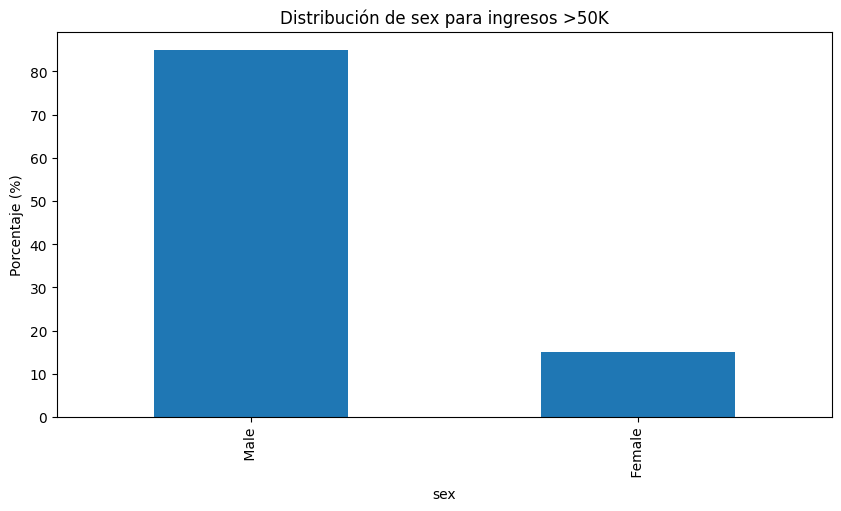

In [ ]:
def Grafico_Barras(feature):
    filtro_ingresos = df['income'].astype(str).str.strip() == ">50K"
    salario = df[filtro_ingresos][feature].value_counts(normalize=True)*100  
    salario.plot(kind='bar', figsize=(10, 5))
    
    plt.title(f"Distribución de {feature} para ingresos >50K")
    plt.ylabel("Porcentaje (%)")
    plt.show()

# Miro el porcentaje de ingresos >50K entre hombres y mujeres
Grafico_Barras("sex")    

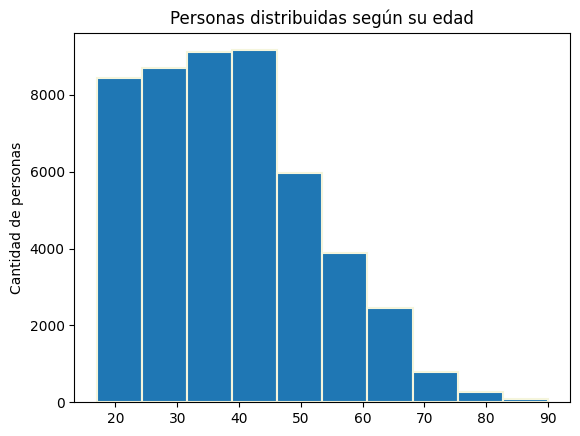

In [ ]:
def histograma (feature, bines=10):
    df[feature].plot(kind="hist", fig=(10, 6), bins=bines, edgecolor="beige", linewidth=1.5)
    plt.title("Personas distribuidas según su edad")
    plt.ylabel("Cantidad de personas")

histograma("age") #Me centro en una variable numérica, la edad, para ver si contiene outliers.

Concatenando la información del momento logramos visualizar: 

Nuestro dataset está conformado por 48842 observaciones y contiene dos tipos de datos: Númericos y Categoricos, donde a penas el 24% de ellos tiene un ingreso mayor a 50K.
En los gráficos integrados se puede observar que más del 80% de las personas que logran este alto ingreso son del genero masculino, y que en su gran mayoría las personas del dataset completo se encuentran entre 25 y 52 años, por lo que aquellas de 70/80/90 años podrían llegar a ser un posible problema, ya que por lo menos el 75% de los datos están por debajo de 48 años. 

Además logramos notar la presencia de valores faltates nulos (" ?"), que conforman el 13% del dataset con un total de 6465 nulls, que solo se encuentran en 3 de nuestras variables (Workclass, Occupation y Native-country).
Finalizando logramos observar una aparente relación entre las variables marital-status y relationship debido a su gran similitud en datos.

Análisis posteriores a realizar:
 - Ver si hay una relación entre los valores nulos de nuestro dataset, para realizar una limpieza del mismo
 - Análizar la aparente relación entre marital-status y relationship

VISUALIZAR RELACIÓN ENTRE NULOS: En este sector se va a analizar si hay una relación entre los datos nulos existentes 

Se utilizó el dataset donde solo aparecen los nulos **df_limpio**, ya que si pongo *.isnull()* no toma en cuenta a los datos mencionados como "?"

In [11]:
#Tuve duda de si la cantidad de nulos en "Workclass" y "Occupation" pertenecen a las mismas personas.
nulos_en_ambas = df_limpio[df_limpio['workclass'].isnull() & df_limpio['occupation'].isnull()]
print(f"Cantidad de personas con nulos en ambas: {len(nulos_en_ambas)}")
nulos_en_ambas.head(100)

Cantidad de personas con nulos en ambas: 2799


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27,54,<NA>,180211,Some-college,10,Married-civ-spouse,<NA>,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,32,<NA>,293936,7th-8th,4,Married-spouse-absent,<NA>,Not-in-family,White,Male,0,0,40,<NA>,<=50K
69,25,<NA>,200681,Some-college,10,Never-married,<NA>,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,<NA>,212759,10th,6,Married-civ-spouse,<NA>,Husband,White,Male,0,0,2,United-States,<=50K
106,17,<NA>,304873,10th,6,Never-married,<NA>,Own-child,White,Female,34095,0,32,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1504,60,<NA>,290593,Masters,14,Married-civ-spouse,<NA>,Husband,White,Male,0,0,40,United-States,<=50K
1544,69,<NA>,473040,5th-6th,3,Divorced,<NA>,Not-in-family,White,Male,0,0,40,United-States,<=50K
1562,75,<NA>,111177,Bachelors,13,Widowed,<NA>,Not-in-family,White,Female,25124,0,16,United-States,>50K
1569,20,<NA>,174714,Some-college,10,Never-married,<NA>,Own-child,White,Male,0,0,16,United-States,<=50K


In [12]:
#Pruebo con aquellas 3 variables que tienen nulos.
nulos_en_ambas = df_limpio[df_limpio['workclass'].isnull() & df_limpio['occupation'].isnull() & df_limpio['native-country'].isnull()]
print(f"Cantidad de personas con nulos en ambas: {len(nulos_en_ambas)}")
nulos_en_ambas.head()

Cantidad de personas con nulos en ambas: 46


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
61,32,<NA>,293936,7th-8th,4,Married-spouse-absent,<NA>,Not-in-family,White,Male,0,0,40,<NA>,<=50K
297,39,<NA>,157443,Masters,14,Married-civ-spouse,<NA>,Wife,Asian-Pac-Islander,Female,3464,0,40,<NA>,<=50K
1152,24,<NA>,35633,Some-college,10,Never-married,<NA>,Not-in-family,White,Male,0,0,40,<NA>,<=50K
1676,64,<NA>,168340,HS-grad,9,Married-civ-spouse,<NA>,Husband,White,Male,0,0,40,<NA>,>50K
2513,47,<NA>,174525,HS-grad,9,Married-civ-spouse,<NA>,Husband,White,Male,3942,0,40,<NA>,<=50K


Decisión Clave:
 - Teniendo en cuenta los datos nulos que aparecen en las tres variables, no hay ninguna objeción para eliminarlos, como aquellos datos nulos entre workclass y occupation, pero considerando los otros 3620 datos nulos dispersados en nuestro dataset posteriormente se decidirá si serán eliminados o rellenados con un valor que no afecte el peso de los demás, ya que sino estariamos eliminando un 13% de información que puede ser valida para el entrenamiento de los modelos.

RELACIÓN DE MULTICOLINEALIDAD ENTRE VARIABLES: Se planteó la idea, de que algunas variables de nuestro dataset parecian estar fuertemente relacionadas.

Valor p de la prueba: 0.0
Las variables están fuertemente relacionadas.


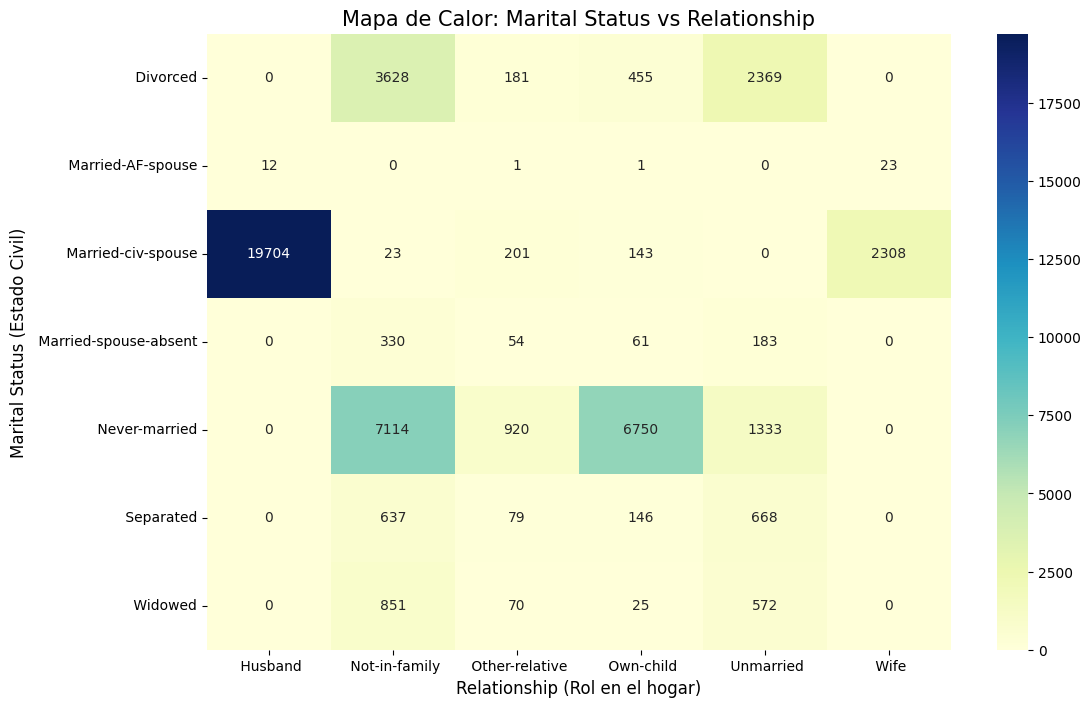

In [ ]:
#Decisión sobre la Multicolinealidad de las Variables "Relationship" y "Marital-status"
tabla_cruzada = pd.crosstab(df['marital-status'], df['relationship'])

# Aplicamos Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_cruzada)
#Al tener variables categoricas puedo aplicar chi cuadrado y no correlación con pearson

print(f"Valor p de la prueba: {p}")
if p < 0.05:
    print("Las variables están fuertemente relacionadas.")

# 2. Creación del gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Mapa de Calor: Marital Status vs Relationship', fontsize=15)
plt.xlabel('Relationship (Rol en el hogar)', fontsize=12)
plt.ylabel('Marital Status (Estado Civil)', fontsize=12)

plt.show()

Mediante este análisis podemos visualizar la fuerte relación entre las variables Marital-status y Relationship, donde vemos que linealmente si una persona está categorizada como esposa o esposo se va a encontrar en el sector de casado, esto me hizo pensar en la variable sex, donde si una persona se encuentra categorizada como esposo u esposa ya define su sexo/genero, aun que eso no me hace pensar en la eliminación de esta variable, ya que por el momento la considero una variable significativa para el ingreso salarial de una persona y además los datos que no son husband y wife no determinan el sexo de la persona.

Pero igualmente voy a aplicar el mismo análisis para ver si estan correlacionadas.

Valor p de la prueba: 0.0
Las variables están fuertemente relacionadas.


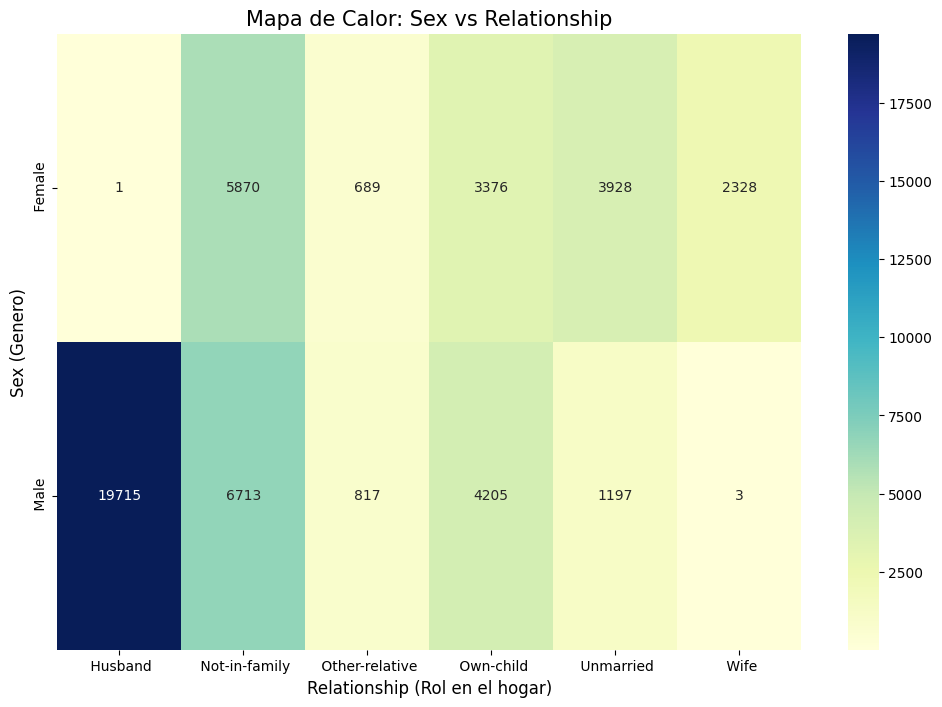

In [14]:
#Demostración de multicolinealidad entre "Relationship" y "Sex"
tabla_cruzada = pd.crosstab(df['sex'], df['relationship'])

# Aplicamos Chi-cuadrado
chi2, p, dof, ex = chi2_contingency(tabla_cruzada)

print(f"Valor p de la prueba: {p}")
if p < 0.05:
    print("Las variables están fuertemente relacionadas.")

# 2. Creación del gráfico
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', cbar=True)

plt.title('Mapa de Calor: Sex vs Relationship', fontsize=15)
plt.xlabel('Relationship (Rol en el hogar)', fontsize=12)
plt.ylabel('Sex (Genero)', fontsize=12)

plt.show()

**SEGUNDA PARTE:** Recategorización y División de Datos

En primera instancia se pensó en recategorizar el dataset completo al realizar el pasaje de variables categoricas a númericas, debido a la gran cantidad de datos(clases) dentro de cada variable, ya que afectaban a la hora de entrenar los modelos.

Por lo que en esta sección se aplicarán unicamente dos tareas:
 - La primera será la transformación de nuestro dataset a un formato unicamente númerico
 - La segunda será la división del dataset.

 EXPLICACIÓN PRIMER SECCIÓN: Se decidió realizar un dataset completamente númerico, con la función de dummies para convertir todos los datos a variables, ya que features como native-country tenian una gran cantidad de datos y afectaban negativamente a la variable respuesta.

 EXPLICACIÓN SEGUNDA SECCIÓN: Se realizó una división de datos 80/20.

PASAJE DE DATOS

In [15]:
# =====================================================================
# 1. ELIMINACIÓN DE FILAS DONDE LOS 3 NULOS COINCIDEN AL MISMO TIEMPO
# =====================================================================

# Primero nos aseguramos de que los "?" sean tratados como NaN reales
df_limpio = df.replace(' ?', pd.NA)

# Creamos la condición: que sea nulo en las tres columnas a la vez (usamos el operador AND: &)
condicion_tres_nulos = (
    df_limpio['workclass'].isnull() & 
    df_limpio['occupation'].isnull() & 
    df_limpio['native-country'].isnull() 
)

condicion_dos_nulos = (
    df_limpio['workclass'].isnull() & 
    df_limpio['occupation'].isnull()
)
# =====================================================================
# 2. TRANSFORMACIÓN DE CATEGÓRICAS A NUMÉRICAS (SIN AGRUPAR)
# =====================================================================
# Filtramos el dataset quedándonos con las filas que NO cumplen esa condición (usamos la virgulilla ~)
df_filtrado = df_limpio[~condicion_tres_nulos].copy()
df_filtrado = df_filtrado[~condicion_dos_nulos].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar los 3 nulos simultáneos: {len(df_filtrado)}")

# Identificamos automáticamente las columnas categóricas (las de tipo object o category)
columnas_categoricas = df_filtrado.select_dtypes(include=['object', 'category']).columns
columnas_categoricas = columnas_categoricas.drop('income')  # Excluimos la variable objetivo "income" para no codificarla ahora

# Creamos una copia del DataFrame para no destruir el anterior
df_numerico = df_filtrado.copy()

# Aplicamos One-Hot Encoding (dummies) a las columnas categóricas
df_numerico = pd.get_dummies(df_numerico, columns=columnas_categoricas, drop_first=False)

# =====================================================================
# 3. VISUALIZACIÓN DE LAS PRIMERAS 100 FILAS
# =====================================================================

# Configuramos Pandas para que nos deje ver todas las columnas sin recortes (...)
pd.set_option('display.max_columns', None)

# Mostramos las primeras 100 filas del nuevo dataset
df_numerico.head(100)

Filas originales: 48842
Filas después de eliminar los 3 nulos simultáneos: 46043


C:\Users\Urano\AppData\Local\Temp\ipykernel_10656\2469136988.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtrado = df_filtrado[~condicion_dos_nulos].copy()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 10th,education_ 11th,education_ 12th,education_ 1st-4th,education_ 5th-6th,education_ 7th-8th,education_ 9th,education_ Assoc-acdm,education_ Assoc-voc,education_ Bachelors,education_ Doctorate,education_ HS-grad,education_ Masters,education_ Preschool,education_ Prof-school,education_ Some-college,marital-status_ Divorced,marital-status_ Married-AF-spouse,marital-status_ Married-civ-spouse,marital-status_ Married-spouse-absent,marital-status_ Never-married,marital-status_ Separated,marital-status_ Widowed,occupation_ Adm-clerical,occupation_ Armed-Forces,occupation_ Craft-repair,occupation_ Exec-managerial,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,relationship_ Husband,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,native-country_ Cambodia,native-country_ Canada,native-country_ China,native-country_ Columbia,native-country_ Cuba,native-country_ Dominican-Republic,native-country_ Ecuador,native-country_ El-Salvador,native-country_ England,native-country_ France,native-country_ Germany,native-country_ Greece,native-country_ Guatemala,native-country_ Haiti,native-country_ Holand-Netherlands,native-country_ Honduras,native-country_ Hong,native-country_ Hungary,native-country_ India,native-country_ Iran,native-country_ Ireland,native-country_ Italy,native-country_ Jamaica,native-country_ Japan,native-country_ Laos,native-country_ Mexico,native-country_ Nicaragua,native-country_ Outlying-US(Guam-USVI-etc),native-country_ Peru,native-country_ Philippines,native-country_ Poland,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,<=50K,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,<=50K,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,<=50K,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,

DIVISIÓN DE DATOS

In [16]:
x = df_numerico.drop("income", axis=1)
y = df_numerico["income"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

**TERCER PARTE:**

En este sector se aplicarán los modelos de Machine Learning seleccionados:
 - El modelo que será utilizado como un baseline es Regresión Logística Binaria
 - Luego se aplicará Bayes Ingenuo, ya que selecciona la clase a la que va a pertenecer la observación, calculando una probabilidad de pertenencia a la misma. Además, a pesar de que asume que todas las variables son independientes se maneja muy bien con variables categoricas
 - Por último se aplicará Boosting con AdaBoost (es el más optimo para variables binarias), donde se centra en el error de su iteración en vez de lo que realiza bien, donde aprenderá de los errores y permitirá un mejor entrenamiento. También lo compararé con XGBoost, ya que a pesar de que se maneja mejor con variables multinomiales probaré ver si termina siendo más óptimo en este caso (únicamente es para probar si cambia en algo o logra una mejora).

 PD: Pensé en aplicar Clasificador de Soporte Vectorial, debido a que separa los datos por un hiperplano, creando una frontera de decisión lineal o no lineal en un espacio de mayor dimensión.

C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[ 1.71325127e-02  6.57900797e-07  1.34185219e-01  3.25670848e-04
   6.49366752e-04  2.37801121e-02  2.23076049e-01 -5.44206084e-01
  -4.32676194e-03 -4.95584103e-01  3.81134504e-02 -9.95846660e-01
  -5.92658119e-01 -2.30981078e-02 -5.95314114e-01 -7.90683444e-01
  -2.68452579e-01 -1.82746143e-01 -3.24719195e-01 -6.27457768e-01
  -4.54257726e-01 -1.94484862e-01 -2.01437916e-01  1.26082454e-01
   4.60721749e-01 -3.22331954e-01  6.75848493e-01 -6.81084811e-02
   5.65471906e-01 -1.92659856e-01 -7.17454345e-01  4.58084623e-02
   5.99248803e-01 -1.76955571e-01 -1.53412437e+00 -3.51673131e-01
  -2.59379306e-01 -1.97669016e-01  5.91172111e-03 -2.85709124e-02
   7.39538666e-01 -9.48342679e-01 -8.15946378e-01 -6.90145931e-01
  -1.36822883e+00 -1.09053211e-01  6.33051377e-01  1.15782590e-01
   2.64141327e-01  3.20645582e-01 -3.11317258e-01 -1.03631552e-01
  -2.44343468e-01 -5.13373867e-01 -1.37741508e+00 -1.01084547e+00
   8.55079747e-01 -2.49725625e-01 -6.00889839e-01 -8.16039258e-01
  -2.50254

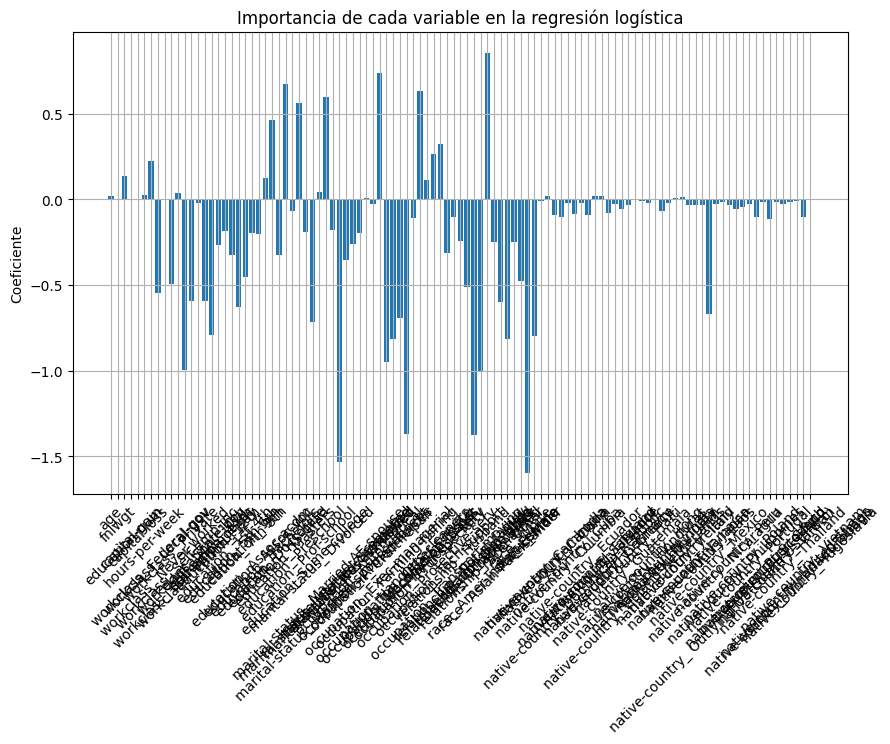

0.8466634088070805
0.8501465957215767


In [17]:
# Corro la regresión logística
clf = LogisticRegression(random_state=0, max_iter=10000).fit(x_train, y_train)

# Miro los coeficientes que se obtuvieron
print(clf.coef_)

# Miro el intercept
print(clf.intercept_)

plt.figure(figsize=(10,6))
plt.bar(x.columns, clf.coef_[0])
plt.xticks(rotation=45)
plt.title("Importancia de cada variable en la regresión logística")
plt.ylabel("Coeficiente")
plt.grid(True)
plt.show()

# Calculo el accuracy en train y test
print(clf.score(x_train, y_train))
print(clf.score(x_test, y_test))

In [18]:
# Crear una tabla con los coeficientes y su significancia estadística


# Obtener los coeficientes del modelo
coeficientes = clf.coef_[0]
nombres_features = x.columns

# Crear un DataFrame con los coeficientes
df_coef = pd.DataFrame({
  'Feature': nombres_features,
  'Coeficiente': coeficientes,
  'Abs_Coeficiente': np.abs(coeficientes)
})

# Ordenar por valor absoluto del coeficiente (descendente)
df_coef = df_coef.sort_values('Abs_Coeficiente', ascending=False)

# Calcular el error estándar y el valor p para cada coeficiente
# Usamos la matriz de covarianza del modelo logístico

# Predicciones en el conjunto de entrenamiento
y_pred_proba = clf.predict_proba(x_train)

# Calcular la matriz de información de Fisher (Hessian)
# Para regresión logística: H = X^T * W * X, donde W es la matriz diagonal de pesos
W = np.diag(y_pred_proba[:, 0] * y_pred_proba[:, 1])  # w_i = p_i * (1 - p_i)
X_train_array = x_train.values.astype(float)
hessian = X_train_array.T @ W @ X_train_array

# Matriz de covarianza = inversa del Hessian
try:
  cov_matrix = np.linalg.inv(hessian)
  std_errors = np.sqrt(np.diag(cov_matrix))
except:
  # Si la matriz no es invertible, usar una aproximación
  std_errors = np.ones(len(coeficientes)) * 0.1

# Calcular z-scores y p-values
z_scores = coeficientes / std_errors
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

# Añadir al DataFrame
df_coef['Std_Error'] = std_errors
df_coef['Z_Score'] = z_scores
df_coef['P_Value'] = p_values
df_coef['Significancia'] = df_coef['P_Value'].apply(
  lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'No significativo'))
)

# Mostrar el top 15 características
top_features = df_coef.head(15)[['Feature', 'Coeficiente', 'Std_Error', 'Z_Score', 'P_Value', 'Significancia']]

print("=" * 120)
print("TOP 15 COVARIABLES CON MAYOR COEFICIENTE (EN VALOR ABSOLUTO)")
print("=" * 120)
print(top_features.to_string(index=False))
print("\n*** p < 0.001 | ** p < 0.01 | * p < 0.05")

TOP 15 COVARIABLES CON MAYOR COEFICIENTE (EN VALOR ABSOLUTO)
                      Feature  Coeficiente  Std_Error   Z_Score      P_Value    Significancia
                  sex_ Female    -1.597374        0.1  0.171325 8.639681e-01 No significativo
marital-status_ Never-married    -1.534124        0.1  0.000007 9.999948e-01 No significativo
      relationship_ Own-child    -1.377415        0.1  1.341852 1.796439e-01 No significativo
    occupation_ Other-service    -1.368229        0.1  0.003257 9.974015e-01 No significativo
      relationship_ Unmarried    -1.010845        0.1  0.006494 9.948188e-01 No significativo
  workclass_ Self-emp-not-inc    -0.995847        0.1  0.237801 8.120353e-01 No significativo
  occupation_ Farming-fishing    -0.948343        0.1  2.230760 2.569700e-02                *
           relationship_ Wife     0.855080        0.1 -5.442061 5.266768e-08              ***
                  race_ Black    -0.816039        0.1 -0.043268 9.654882e-01 No significativo

**NOTA POST CLASE REVISIÓN 27/05** (Continuación 29/05)

Posterior a la clase de revisión, decidí aplicar principalmente el baseline, el cúal es Regresión Logística sin meterme tan en las variables para luego aplicar redes neuronales.

La decisión sobre como quedará organizado el dataset es:
 - Se obtendran tres divisiones distintas del dataset: LabelEncoder sin modificación alguna de los datos unicamente el pasaje númerico; dummies y recategorización donde se reagruparan los datos dentro de las variables.

DEFINICIÓN CON DUMMIES

In [19]:
# =====================================================================
# 1. ELIMINACIÓN DE FILAS DONDE LOS 3 NULOS COINCIDEN AL MISMO TIEMPO
# =====================================================================

# Primero nos aseguramos de que los "?" sean tratados como NaN reales
df_limpio = df.replace(' ?', pd.NA)

# Creamos la condición: que sea nulo en las tres columnas a la vez (usamos el operador AND: &)
condicion_tres_nulos = (
    df_limpio['workclass'].isnull() & 
    df_limpio['occupation'].isnull() & 
    df_limpio['native-country'].isnull() 
)

condicion_dos_nulos = (
    df_limpio['workclass'].isnull() & 
    df_limpio['occupation'].isnull()
)
# =====================================================================
# 2. TRANSFORMACIÓN DE CATEGÓRICAS A NUMÉRICAS (SIN AGRUPAR)
# =====================================================================
# Filtramos el dataset quedándonos con las filas que NO cumplen esa condición (usamos la virgulilla ~)
df_filtrado = df_limpio[~condicion_tres_nulos].copy()
df_filtrado = df_filtrado[~condicion_dos_nulos].copy()

print(f"Filas originales: {len(df)}")
print(f"Filas después de eliminar los 3 nulos simultáneos: {len(df_filtrado)}")

# Identificamos automáticamente las columnas categóricas (las de tipo object o category)
columnas_categoricas = df_filtrado.select_dtypes(include=['object', 'category']).columns
columnas_categoricas = columnas_categoricas.drop('income')  # Excluimos la variable objetivo "income" para no codificarla ahora

# Creamos una copia del DataFrame para no destruir el anterior
df_numerico = df_filtrado.copy()

# Aplicamos One-Hot Encoding (dummies) a las columnas categóricas
df_numerico = pd.get_dummies(df_numerico, columns=columnas_categoricas, drop_first=False)

# =====================================================================
# 3. VISUALIZACIÓN DE LAS PRIMERAS 100 FILAS
# =====================================================================

# Configuramos Pandas para que nos deje ver todas las columnas sin recortes (...)
pd.set_option('display.max_columns', None)

# Mostramos las primeras 100 filas del nuevo dataset
df_numerico.head(100)

#Sumamos todos los nulos por columna
total_nulos_por_columna = df_numerico.isnull().sum()
print("Conteo de nulos por columna:")
print(total_nulos_por_columna[total_nulos_por_columna > 0])

#Total de nulos en el dataset
total_general = df_numerico.isnull().sum().sum()
print(f"\nTotal general de valores nulos en el dataset: {total_general}")

Filas originales: 48842
Filas después de eliminar los 3 nulos simultáneos: 46043
Conteo de nulos por columna:
Series([], dtype: int64)

Total general de valores nulos en el dataset: 0


C:\Users\Urano\AppData\Local\Temp\ipykernel_10656\808654853.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtrado = df_filtrado[~condicion_dos_nulos].copy()


Al copiar el codigo de arriba para luego continuar, vi que en las 106 columnas, no habia ninguna que tuviera Occupation_NaN o Occupation_?, por lo que aplique un código para hacer un nuevo conteo de nulos.
Lo que dió es que no hay nulos, aún que unicamente elimine los que coincidian.

Me hizo ruido que de los nulos totales eliminados no apareciera en el cuadro de dummies anterior ninguna columna que hable de los nulos que quedaron

**Minutos después pensé en esto:**

Idea: En total hay 6465 nulos como celdas vacias sin tener en cuenta las coincidencias, pero esas coincidencias en realidad no son el numero de observaciones que tienen nulos, por lo que voy a visualizar primero cuantas observaciones en total tienen nulos y si al eliminar las que coinciden verdaderamente quedan observaciones con nulos.

No es lo mismo la totalidad de nulos, que la totalidad de observaciones con nulos, por lo que al eliminar las observaciones donde coinciden estos nulos puede que ese sea el error que nos dice que ya no hay nulos.

In [ ]:
# 1. Aseguramos que el dataset original interprete el "?" como nulo verdadero
df_original_limpio = df.copy()
for col in df_original_limpio.select_dtypes(include=['object']):
    df_original_limpio[col] = df_original_limpio[col].astype(str).str.strip()

# Reemplazamos el "?" por el nulo oficial de Pandas
df_original_limpio = df_original_limpio.replace('?', pd.NA)


# =====================================================================
# METRICAS DE OBSERVACIONES (FILAS) VS CELDAS
# =====================================================================

# .isnull().any(axis=1) analiza horizontalmente cada fila. 
# Devuelve True si la fila tiene al menos un nulo en alguna columna.
filas_con_al_menos_un_nulo = df_original_limpio.isnull().any(axis=1)

# Contamos cuántas filas dieron True
total_filas_afectadas = filas_con_al_menos_un_nulo.sum()

# Calculamos las filas que están 100% perfectas (las que NO tienen ningún nulo)
total_filas_perfectas = len(df_original_limpio) - total_filas_afectadas

# Calculamos el total de celdas nulas totales para comparar
total_celdas_nulas = df_original_limpio.isnull().sum().sum()


print("=== ANÁLISIS DE OBSERVACIONES AFECTADAS ===")
print(f"Cantidad total de FILAS (observaciones) en el dataset: {len(df_original_limpio)}")
print(f"Cantidad de FILAS que tienen al menos un dato faltante: {total_filas_afectadas}")
print(f"Cantidad de FILAS que están 100% completas (sin nulos): {total_filas_perfectas}")
print("-" * 50)
print(f"Cantidad total de CELDAS nulas en todo el tablero: {total_celdas_nulas}")
print(f"Promedio de celdas nulas por cada fila afectada: {round(total_celdas_nulas / total_filas_afectadas, 2)}")

=== ANÁLISIS DE OBSERVACIONES AFECTADAS ===
Cantidad total de FILAS (observaciones) en el dataset: 48842
Cantidad de FILAS que tienen al menos un dato faltante: 3620
Cantidad de FILAS que están 100% completas (sin nulos): 45222
--------------------------------------------------
Cantidad total de CELDAS nulas en todo el tablero: 6465
Promedio de celdas nulas por cada fila afectada: 1.79


Luego de esto logramos ver que de las 3620 observaciones vacias, 2845 son el total de aquellas que coinciden entre nulos, por lo que solo 775 no coinciden en nada.

En comparación total de los datos (48842) y teniendo en cuenta las observaciones nulas totales (7.4%), es relativamente insignificante la cantidad de datos a eliminar con el volumen total del dataset.

Aún que la IA me dijo que reconcidere la elección, por el posible sesgo y que supuestamente esas personas que tienen nulos es porque nunca trabajaron, aun así decido eliminarlos porque donde dice que nunca trabajaron es en estas mismas variables que tienen nulos, por lo que veo insignificante buscar muchas vueltas por la cantidad total de datos que quedan.

*NUEVA IMPLEMENTACIÓN DE LOS MODELOS SIN NULOS*

In [21]:
#===================================
#            DUMMIES
#===================================

#LIMPIEZA Y ELIMINACIÓN DE NULOS
# Primero nos aseguramos de que no haya espacios fantasmas que camuflen el "?"
df_limpio = df.copy()
for col in df_limpio.select_dtypes(include=['object']):
    df_limpio[col] = df_limpio[col].astype(str).str.strip()

# Convertimos el "?" en nulos reales de Pandas (pd.NA)
df_limpio = df_limpio.replace('?', pd.NA)

# .dropna() elimina CUALQUIER fila que tenga al menos un nulo
# Esto va a borrar las 3.620 filas afectadas (solapadas y dispersas)
df_filtrado_dummies = df_limpio.dropna().copy()

print(f"Filas originales del dataset: {len(df)}")
print(f"Filas remanentes tras eliminar TODOS los nulos: {len(df_filtrado_dummies)}")
print(f"Total de filas eliminadas: {len(df) - len(df_filtrado_dummies)}")

#TRANSFORMACIÓN DE CATEGORICAS A NUMÉRICAS

# Identificamos automáticamente las columnas categóricas (object o category)
df_filtrado_dummies['income'] = df_filtrado_dummies['income'].map({'<=50K': 0, '>50K': 1}) #Hacemos la variable respuesta binaria
columnas_categoricas = df_filtrado_dummies.select_dtypes(include=['object', 'category']).columns


# Creamos una copia para el dataset numérico final
df_numerico = df_filtrado_dummies.copy()

# Aplicamos One-Hot Encoding (dummies) a las columnas categóricas
df_numerico = pd.get_dummies(df_numerico, columns=columnas_categoricas, drop_first=False)

#VISUALIZAMOS LAS PRIMERAS 100 FILAS DEL DATASET CON DUMMIES
# Configuramos Pandas para que nos deje ver todas las columnas sin recortes
pd.set_option('display.max_columns', None)

# Mostramos las primeras 100 filas del nuevo dataset impecable
df_numerico.head(100)

Filas originales del dataset: 48842
Filas remanentes tras eliminar TODOS los nulos: 45222
Total de filas eliminadas: 3620


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [22]:
#=============================
#       Label Encoder
#=============================

#LIMPIEZA Y ELIMINACIÓN DE NULOS
# Primero nos aseguramos de que no haya espacios fantasmas que camuflen el "?"
df_limpio = df.copy()
for col in df_limpio.select_dtypes(include=['object']):
    df_limpio[col] = df_limpio[col].astype(str).str.strip()

# Convertimos el "?" en nulos reales de Pandas (pd.NA)
df_limpio = df_limpio.replace('?', pd.NA)

# .dropna() elimina CUALQUIER fila que tenga al menos un nulo
# Esto va a borrar las 3.620 filas afectadas (solapadas y dispersas)
df_filtrado_encoder = df_limpio.dropna().copy()

# Identificamos automáticamente las columnas categóricas (las de tipo object o category)
columnas_categoricas = df_filtrado_encoder.select_dtypes(include=['object', 'category']).columns

# Creamos una copia del DataFrame para no destruir el anterior
df_numerico_encoder = df_filtrado_encoder.copy()

# Aplicamos LabelEncoder a cada columna categórica
le = LabelEncoder()
for col in columnas_categoricas:
    # Convertimos a string por seguridad (para evitar problemas si quedó algún NaN suelto)
    df_numerico_encoder[col] = df_numerico_encoder[col].astype(str)
    # Ajustamos el codificador y transformamos la columna
    df_numerico_encoder[col] = le.fit_transform(df_numerico_encoder[col])

#Vemos como quedó con las primeras 100 filas
# Configuramos Pandas para que nos deje ver todas las columnas sin recortes (...)
pd.set_option('display.max_columns', None)

# Mostramos las primeras 100 filas del nuevo dataset
df_numerico_encoder.head(100)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,20,2,188300,15,10,4,12,3,4,0,0,0,40,38,0
104,29,2,103432,11,9,4,2,1,4,1,0,0,40,38,0
105,32,3,317660,11,9,2,2,0,4,1,7688,0,40,38,1
107,30,2,194901,1,7,4,5,3,4,1,0,0,40,38,0


In [23]:
# ==================================
#         Recategorización
# ==================================

# LIMPIEZA Y ELIMINACIÓN DE NULOS
df_limpio = df.copy()
for col in df_limpio.select_dtypes(include=['object']):
    df_limpio[col] = df_limpio[col].astype(str).str.strip()

df_limpio = df_limpio.replace('?', pd.NA)
df_filtrado_recate = df_limpio.dropna().copy()

print(f"Filas originales del dataset: {len(df)}")
print(f"Filas remanentes tras eliminar TODOS los nulos: {len(df_filtrado_recate)}")
print("-" * 60)


# DEFINICIÓN DE FUNCIONES DE MAPEO 
def map_country(country):
    north_am = ['United-States', 'Canada', 'Outlying-US(Guam-USVI-etc)']
    latam = ['Mexico', 'Puerto-Rico', 'El-Salvador', 'Cuba', 'Jamaica', 'Dominican-Republic', 
             'Guatemala', 'Columbia', 'Haiti', 'Nicaragua', 'Peru', 'Ecuador', 
             'Trinadad&Tobago', 'Honduras']
    europe = ['Holand-Netherlands', 'Hungary', 'Scotland', 'Yugoslavia', 'Ireland', 'France', 
              'Greece', 'Portugal', 'Poland', 'Italy', 'England', 'Germany']
    asia = ['Philippines', 'India', 'China', 'Japan', 'Vietnam', 'Taiwan', 'Iran', 
            'Thailand', 'Hong', 'Cambodia', 'Laos', 'South'] # Agrupamos 'South' en Asia
    
    if country in north_am: return 0
    if country in latam: return 1
    if country in europe: return 2
    if country in asia: return 3
    return 0 # Por defecto al grupo mayoritario (Norteamérica) si quedara alguno menor

def map_occupation(occ):
    if occ in ['Prof-specialty', 'Exec-managerial']: return 0
    if occ in ['Adm-clerical', 'Sales', 'Tech-support']: return 1
    if occ in ['Craft-repair', 'Machine-op-inspct', 'Transport-moving', 'Handlers-cleaners', 'Farming-fishing']: return 2
    # El resto cae en servicios generales o fuerzas armadas
    return 3 

def map_education(edu):
    prim = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']
    uni = ['Bachelors', 'Assoc-voc', 'Assoc-acdm', 'Some-college']
    post = ['Doctorate', 'Masters', 'Prof-school']
    
    if edu in prim: return 0
    if edu == 'HS-grad': return 1
    if edu in uni: return 2
    if edu in post: return 3
    return 0

def map_workclass(wc):
    if wc == 'Private': return 0
    if wc in ['Local-gov', 'State-gov', 'Federal-gov']: return 1
    if wc in ['Self-emp-not-inc', 'Self-emp-inc']: return 2
    # Sin empleo o trabajo sin paga (ej: Never-worked, Without-pay)
    return 3 


# APLICACIÓN DE MAPEOS SOBRE EL DATASET FILTRADO
print("Aplicando mapeos y codificaciones...")

df_filtrado_recate['income'] = df_filtrado_recate['income'].map({'<=50K': 0, '>50K': 1})
df_filtrado_recate['sex'] = df_filtrado_recate['sex'].map({'Male': 0, 'Female': 1})

df_filtrado_recate['race'] = df_filtrado_recate['race'].map({
    'White': 0, 'Black': 1, 'Asian-Pac-Islander': 2, 'Amer-Indian-Eskimo': 2, 'Other': 2
})

df_filtrado_recate['marital-status'] = df_filtrado_recate['marital-status'].map({
    'Married-civ-spouse': 0, 'Married-AF-spouse': 0, 'Married-spouse-absent': 0,
    'Never-married': 1, 'Divorced': 2, 'Separated': 2, 'Widowed': 2
})

# LabelEncoder para Relationship, ya que es de la que depende Marital-status decidí dejarla tal cuál está
le = LabelEncoder()
df_filtrado_recate['relationship'] = le.fit_transform(df_filtrado_recate['relationship'].astype(str))

# Aplicación de las funciones limpias
df_filtrado_recate['native-country'] = df_filtrado_recate['native-country'].apply(map_country)
df_filtrado_recate['occupation'] = df_filtrado_recate['occupation'].apply(map_occupation)
df_filtrado_recate['education'] = df_filtrado_recate['education'].apply(map_education)
df_filtrado_recate['workclass'] = df_filtrado_recate['workclass'].apply(map_workclass)


# ARMADO DEL DATASET FINAL: LAS 15 VARIABLES TOTALES

columnas_finales = [
    'age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 
    'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 
    'income' 
]

df_numerico_recate = df_filtrado_recate[columnas_finales].copy()
df_numerico = df_numerico_recate.apply(pd.to_numeric)

print("\n--- Verificación del Dataset Final ---")
print(f"Dimensiones de df_numerico: {df_numerico.shape} (45222 filas, 15 columnas)")

#Visualización de las primeras 100 filas 
pd.set_option('display.max_columns', None)
df_numerico_recate.head(100)

Filas originales del dataset: 48842
Filas remanentes tras eliminar TODOS los nulos: 45222
------------------------------------------------------------
Aplicando mapeos y codificaciones...

--- Verificación del Dataset Final ---
Dimensiones de df_numerico: (45222, 15) (45222 filas, 15 columnas)


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
0,39,77516,13,2174,0,40,1,2,1,1,1,0,0,0,0
1,50,83311,13,0,0,13,2,2,0,0,0,0,0,0,0
2,38,215646,9,0,0,40,0,1,2,2,1,0,0,0,0
3,53,234721,7,0,0,40,0,0,0,2,0,1,0,0,0
4,28,338409,13,0,0,40,0,2,0,0,5,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,20,188300,10,0,0,40,0,2,1,1,3,0,1,0,0
104,29,103432,9,0,0,40,0,1,1,2,1,0,0,0,0
105,32,317660,9,7688,0,40,2,1,0,2,0,0,0,0,1
107,30,194901,7,0,0,40,0,0,1,2,3,0,0,0,0


Ya creamos las tres posibles separaciones del dataset, por el medio hubo dudas de eliminación de limpieza repetida y cambio de nombre de variables hasta que todo funcionó perfecto.

Voy a probarlo en regresión logística para analizar como funciona cada uno.

In [ ]:
#========================================================================================
# Divión de Datos de los 3 datasets numéricos (dummies, label encoder y recategorización)
#========================================================================================

#Para igualdad de análisis todas tendran la misma división de datos.
x_dummies = df_numerico.drop("income", axis=1)
y_dummies = df_numerico["income"]

x_train_dum, x_test_dum, y_train_dum, y_test_dum = train_test_split(x_dummies, y_dummies, test_size=0.20, random_state=42, stratify=y_dummies)
x_val_dum, x_test_dumm, y_val_dum, y_test_dumm = train_test_split(x_test_dum, y_test_dum, test_size=0.5, random_state=42, stratify=y_test_dum)

x_enc = df_numerico_encoder.drop("income", axis=1)
y_enc = df_numerico_encoder["income"]

x_train_enc, x_test_enc, y_train_enc, y_test_enc = train_test_split(x_enc, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
x_val_enc, x_test_enco, y_val_enc, y_test_enco = train_test_split(x_test_enc, y_test_enc, test_size=0.5, random_state=42, stratify=y_test_enc)

x_rec = df_numerico_recate.drop("income", axis=1)
y_rec = df_numerico_recate["income"]

x_train_rec, x_test_rec, y_train_rec, y_test_rec = train_test_split(x_rec, y_rec, test_size=0.20, random_state=42, stratify=y_rec)
x_val_rec, x_test_reca, y_val_rec, y_test_reca = train_test_split(x_test_rec, y_test_rec, test_size=0.5, random_state=42, stratify=y_test_rec)

In [25]:
#Nota Lunes 08/06: primera regresión logística aplicada en 29/05 

clf1 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_dum, y_train_dum)
clf2 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_enc, y_train_enc)
clf3 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_rec, y_train_rec)

# Miro los coeficientes que se obtuvieron
print(clf1.coef_)
print(clf2.coef_)
print(clf3.coef_)


# Miro el intercept
print(clf1.intercept_)
print(clf2.intercept_)
print(clf3.intercept_)


# =====================================================================
#             ETAPA DE TEST: EVALUACIÓN DE LOS 3 MODELOS
# =====================================================================


# 1. El modelo predice usando los datos de prueba (X_test) que tenía guardados
y_pred_dum = clf1.predict(x_test_dum)
y_pred_enc = clf2.predict(x_test_enc)
y_pred_rec = clf3.predict(x_test_rec)


# 2. Comparamos las predicciones con las respuestas reales (y_test)
print("=== REPORTE DE RENDIMIENTO: ENFOQUE 1 (DUMMIES) ===")
print(classification_report(y_test_dum, y_pred_dum))
print("-" * 60)

print("=== REPORTE DE RENDIMIENTO: ENFOQUE 2 (ENCODER) ===")
print(classification_report(y_test_enc, y_pred_enc))
print("-" * 60)

print("=== REPORTE DE RENDIMIENTO: ENFOQUE 3 (RECATEGORIZADO) ===")
print(classification_report(y_test_rec, y_pred_rec)) 

C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

[[ 1.62845327e-02 -2.86173923e-06 -4.09465008e-03  3.41447322e-04
   7.81780782e-04 -2.95351895e-02  5.12763225e-03  1.22681392e-02
  -4.14974600e-02 -4.49731692e-02 -6.25091351e-02 -5.20240370e-03
  -1.56140881e-02 -1.37300694e-03]]
[[ 2.37501611e-02 -4.10362155e-03 -1.88655247e-06 -9.95963334e-03
   5.43742791e-03 -1.43827483e-02 -5.29179196e-03 -1.58262400e-02
  -5.31404262e-03  2.03394116e-03  3.32609082e-04  8.16394702e-04
   1.26397807e-02 -6.37196830e-02]]
[[ 1.62845327e-02 -2.86173923e-06 -4.09465008e-03  3.41447322e-04
   7.81780782e-04 -2.95351895e-02  5.12763225e-03  1.22681392e-02
  -4.14974600e-02 -4.49731692e-02 -6.25091351e-02 -5.20240370e-03
  -1.56140881e-02 -1.37300694e-03]]
[-0.00941871]
[-0.00193333]
[-0.00941871]
=== REPORTE DE RENDIMIENTO: ENFOQUE 1 (DUMMIES) ===
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      6803
           1       0.67      0.27      0.39      2242

    accuracy                           0

C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


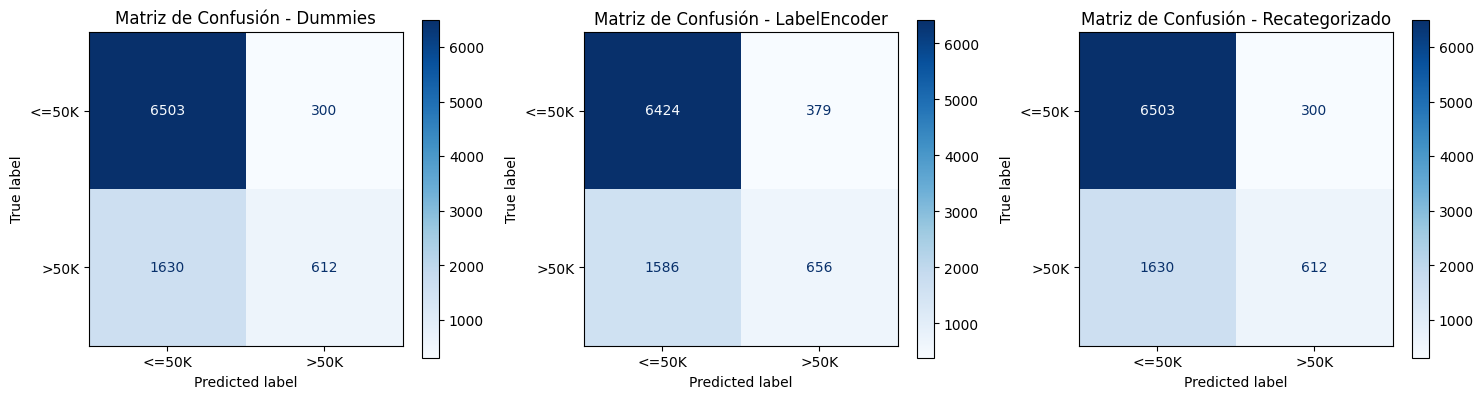

In [ ]:
#Matriz de confusión para cada modelo con sus respectivos resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dummies
cm_dum = confusion_matrix(y_test_dum, y_pred_dum)
disp_dum = ConfusionMatrixDisplay(confusion_matrix=cm_dum, display_labels=['<=50K', '>50K'])
disp_dum.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusión - Dummies')

# LabelEncoder
cm_enc = confusion_matrix(y_test_enc, y_pred_enc)
disp_enc = ConfusionMatrixDisplay(confusion_matrix=cm_enc, display_labels=['<=50K', '>50K'])
disp_enc.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Matriz de Confusión - LabelEncoder')

# Recategorizado
cm_rec = confusion_matrix(y_test_rec, y_pred_rec)
disp_rec = ConfusionMatrixDisplay(confusion_matrix=cm_rec, display_labels=['<=50K', '>50K'])
disp_rec.plot(ax=axes[2], cmap='Blues')
axes[2].set_title('Matriz de Confusión - Recategorizado')

plt.tight_layout()
plt.show()

In [ ]:
#====================================================================
#   Nueva REGRESIÓN LOGÍSTICA con cambio de DIVISIÓN DE DATOS (08/06)
#====================================================================
#Luego de redes neuronales, noté la diferencia de datos en los resultados
# y me di cuenta que no habia agregrado la validación/Dev en este sector, ya que antes el trabajo solo contaba con train y test.

clf1 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_dum, y_train_dum)
clf2 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_enc, y_train_enc)
clf3 = LogisticRegression(random_state=0, max_iter=100).fit(x_train_rec, y_train_rec)

print("=== COEFICIENTES E INTERCEPTOS ===")
print("Enfoque 1 (Dummies) Coef:", clf1.coef_, "Intercept:", clf1.intercept_)
print("Enfoque 2 (Encoder) Coef:", clf2.coef_, "Intercept:", clf2.intercept_)
print("Enfoque 3 (Recate) Coef:", clf3.coef_, "Intercept:", clf3.intercept_)
print("-" * 60)


# Validación de los modelos

# Usamos el set de validación para calcular el Log-Loss y verificar sobreajuste
print("=== DIAGNÓSTICO EN SET DE VALIDACIÓN (LOG-LOSS) ===")

loss_train_rec = log_loss(y_train_rec, clf3.predict_proba(x_train_rec))
loss_val_rec = log_loss(y_val_rec, clf3.predict_proba(x_val_rec))

print(f"Enfoque 3 Recategorizado -> Log-Loss Train: {loss_train_rec:.4f} | Log-Loss Val: {loss_val_rec:.4f}")
# Si loss_val es muy similar a loss_train, confirmamos que el modelo generaliza perfecto.
print("-" * 60)


# Evaluación de los tres modelos

# 1. El modelo predice usando los datos de prueba (X_test) que tenía guardados
y_pred_dum = clf1.predict(x_test_dumm)
y_pred_enc = clf2.predict(x_test_enco)
y_pred_rec = clf3.predict(x_test_reca)

# 2. Comparamos las predicciones con las respuestas reales (y_test)
print("=== REPORTE DE RENDIMIENTO: ENFOQUE 1 (DUMMIES) ===")
print(classification_report(y_test_dumm, y_pred_dum))
print("-" * 60)

print("=== REPORTE DE RENDIMIENTO: ENFOQUE 2 (ENCODER) ===")
print(classification_report(y_test_enco, y_pred_enc))
print("-" * 60)

print("=== REPORTE DE RENDIMIENTO: ENFOQUE 3 (RECATEGORIZADO) ===")
print(classification_report(y_test_reca, y_pred_rec))


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

=== COEFICIENTES E INTERCEPTOS ===
Enfoque 1 (Dummies) Coef: [[ 1.62845327e-02 -2.86173923e-06 -4.09465008e-03  3.41447322e-04
   7.81780782e-04 -2.95351895e-02  5.12763225e-03  1.22681392e-02
  -4.14974600e-02 -4.49731692e-02 -6.25091351e-02 -5.20240370e-03
  -1.56140881e-02 -1.37300694e-03]] Intercept: [-0.00941871]
Enfoque 2 (Encoder) Coef: [[ 2.37501611e-02 -4.10362155e-03 -1.88655247e-06 -9.95963334e-03
   5.43742791e-03 -1.43827483e-02 -5.29179196e-03 -1.58262400e-02
  -5.31404262e-03  2.03394116e-03  3.32609082e-04  8.16394702e-04
   1.26397807e-02 -6.37196830e-02]] Intercept: [-0.00193333]
Enfoque 3 (Recate) Coef: [[ 1.62845327e-02 -2.86173923e-06 -4.09465008e-03  3.41447322e-04
   7.81780782e-04 -2.95351895e-02  5.12763225e-03  1.22681392e-02
  -4.14974600e-02 -4.49731692e-02 -6.25091351e-02 -5.20240370e-03
  -1.56140881e-02 -1.37300694e-03]] Intercept: [-0.00941871]
------------------------------------------------------------
=== DIAGNÓSTICO EN SET DE VALIDACIÓN (LOG-LOSS) ==

C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


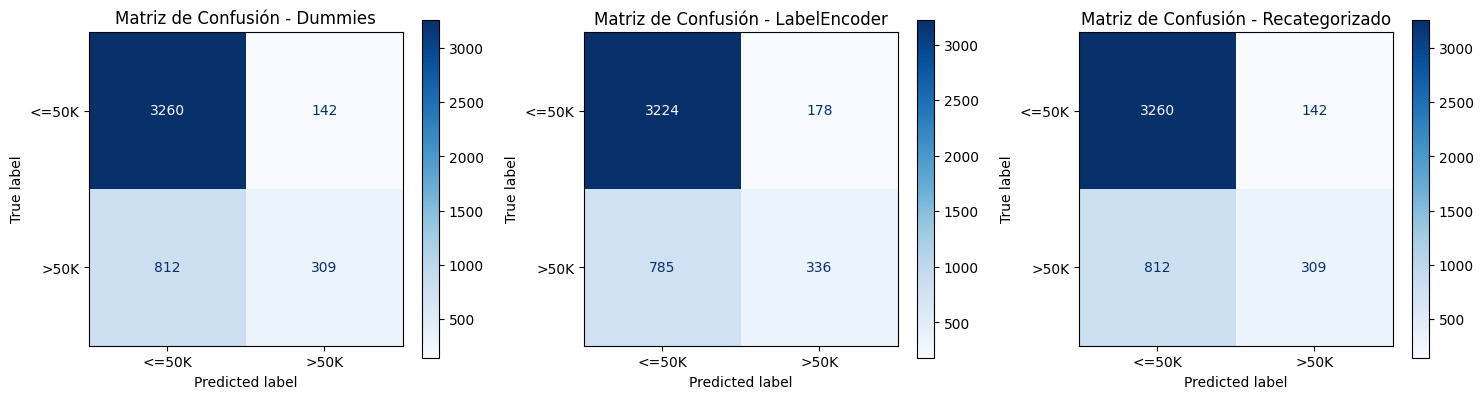

In [28]:
#DIVISIÓN DE DATOS: TRAIN, VAL, TEST (08/06)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dummies
cm_dum = confusion_matrix(y_test_dumm, y_pred_dum)
disp_dum = ConfusionMatrixDisplay(confusion_matrix=cm_dum, display_labels=['<=50K', '>50K'])
disp_dum.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusión - Dummies')

# LabelEncoder
cm_enc = confusion_matrix(y_test_enco, y_pred_enc)
disp_enc = ConfusionMatrixDisplay(confusion_matrix=cm_enc, display_labels=['<=50K', '>50K'])
disp_enc.plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Matriz de Confusión - LabelEncoder')

# Recategorizado
cm_rec = confusion_matrix(y_test_reca, y_pred_rec)
disp_rec = ConfusionMatrixDisplay(confusion_matrix=cm_rec, display_labels=['<=50K', '>50K'])
disp_rec.plot(ax=axes[2], cmap='Blues')
axes[2].set_title('Matriz de Confusión - Recategorizado')

plt.tight_layout()
plt.show()

Al ver esto logro ver el techo de aprendizaje que tiene la regresión logística, ya que a pesar de la estructuración de los datos los resultados de prueba son casi identicos en los tres casos.

Sobre la matriz de confusión y métricas de evaluación logramos notar que no logra predecir bien cuales son aquellas personas que cobran >50k que a mi consideración es la clase más importante en estos caso.
¿Por qué es más importante saber predecir quienes cobran >50K? Basicamente por el hecho de que son la minoría, ya sabemos cuales caracteristicas tienen para cobrar <50K y que son el 76% del dataset, pero no logra encontrar o aprender cuales son las caracteristicas para que una persona cobre más de 50K.

En este caso necesitamos del f1-score ya que busco el equilibrio entre precision y recall, donde necesito que haya un 50 y 50 entre lo que predijo bien y sobre el total de los que cobraban >50k y no erro al predecir.
En estos casos precisión es bastante alto (0.7), pero necesito subir el recall a costa de este porque es el que nos determina que tan errado esta el modelo.

**NOTA**: Lunes 08/06 podemos observar que la nueva división de datos unicamente mejoró un 0.01 el recall, aun que no se sacrificó nada de precision ya que también mejoró un 0.02

**PRÓXIMO PASO:** Aplicar Redes Neuronales y ver si hay mejora

Aplicamos unicamente la red neuronal con Early Stopping para que determine hasta donde hay mejora y no corra indeterminadamente sin sentido.
Al ver que es crucial escalar los datos para aplicar redes neuronales, posterior a probarlo sin ello, se lo voy a aplicar para ver si realmente representa una mejora.

En este caso no aplico Dropout, ni patience, o demás cosas ya que quiero probarlos por separado y ver si mejoran en algo el modelo y cual es el verdadero problema.

In [29]:
# Definir el modelo de red neuronal
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_dum.shape[1],), kernel_regularizer=l2(0.001)),

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
# Usamos 'Adam' como optimizador, 'binary_crossentropy' como función de pérdida para clasificación binaria,
# y 'accuracy' como métrica principal.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Resumen del modelo de red neuronal:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Definir la llamada de Early Stopping
# Monitorea la 'val_loss' (pérdida en el conjunto de validación)
# 'patience=10' significa que esperará 10 épocas sin mejora antes de detenerse
# 'restore_best_weights=True' restaurará los pesos del modelo de la mejor época
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_dum, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=32, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_dum, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")


Entrenando el modelo...
Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6638 - loss: 235.2031 - val_accuracy: 0.7842 - val_loss: 77.8122
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6764 - loss: 58.9948 - val_accuracy: 0.7846 - val_loss: 32.6098
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6809 - loss: 20.6090 - val_accuracy: 0.7640 - val_loss: 3.9749
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6802 - loss: 5.6762 - val_accuracy: 0.7822 - val_loss: 1.2931
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7509 - loss: 0.8206 - val_accuracy: 0.7877 - val_loss: 0.7748
Epoch 6/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7762 - loss: 0.6688 - val_accuracy: 0.7862 - val_loss: 0.6404
Epoch 7/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7826 - loss: 0.5968 - val_accuracy: 0.7890 - val_loss: 0.5791
Epoch 8/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/st

In [31]:
# Evaluar el modelo en el conjunto de prueba
loss, accuracy = model.evaluate(x_test_dumm, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_dumm)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Precisión del modelo en el conjunto de prueba: 0.7915
Pérdida del modelo en el conjunto de prueba: 0.5580
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step

Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      3402
           1       0.82      0.20      0.32      1121

    accuracy                           0.79      4523
   macro avg       0.81      0.59      0.60      4523
weighted avg       0.80      0.79      0.74      4523



En este caso representa un aprendizaje bastante parecido a lo que estaba en la regresión logística, ya que el modelo se vuelve experto prediciendo a la clase mayoritaria "0"(<=50K), donde su f1-score es altisimo al igual que el recall, y... si este dataset solo se basara en la variables respuesta 0 sería excelente.
Pero el verdadero problema se encuentra al intentar predecir la variable 1 (>50K) que son la clase minoritaria

NOTA 08/06: Que mi red neuronal haya comenzado con una perdida de 143 y bajado a 0.5616 significa que estaba totalmente perdida, lo bueno es que bajo hasta un número considerable que puede ser mejorado y que pudo enderezar el rumbo al aprender, abajo voy a aplicar el mismo modelo pero con dropout, para agarrar/tirar un poco más de la cuerda al aprender.

Aun que noté que cada vez que ejecuto la red neuronal con early stopping dispara epocas muy distintas, primero tiró 98 epocas, después 52, luego 13 y ahora 29.
No sé a que se deba la gran variación de epocas pero es algo que posteriormente voy a aclarar, por ahora creo que es por algún tema en como realicé la división de datos o porque probé principalmente sin estandarizarlos.
Ya que fue ejecutado nuevamente, el error inicial bajó considerablemente de 143 a 0.66 y el más bajo a 0.50

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


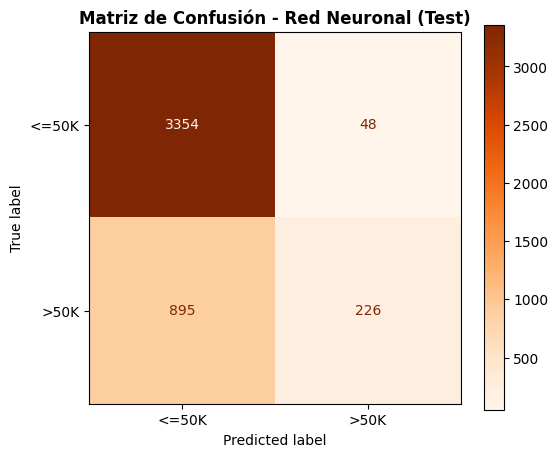

In [ ]:
#Matriz de confusión de la primera red neuronal aplicada sin estandarización ni apagado lectivo de neuronas.

y_prob_red = model.predict(x_test_dumm)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_dumm, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Matriz de Confusión - Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

**Lunes 08/06**

Revisé el código del 29/05, en donde cambié la división de datos de train y test a train, val, test (no dejé el código anterior por que era una repetición innecesaria donde unicamente agregrué lineas)

Luego el día de hoy, voy a continuar con el código y arreglar la regresión Logística (mostrado arriba, en la misma sección de código) porque no registró al val, así puedo compararlo con redes neuronales.
Además voy a analizar mi red neuronal y probar nuevos metodos para su aprendizaje.

Antes de continuar, al ver que predice tan mal a la clase minoritaria, me vino a la cabeza los nulos eliminados.

Teoría: Las personas con salario >50K en el dataset original eran tan solo 11687, por lo que al estar en desventaja quiero verificar si los nulos eliminados redujeron aún más esta clase minoritaria, lo que explicaría la baja precisión en esa categoría.

In [33]:

for col in columnas_categoricas:
    print(f"Columna: {col}")
    print(df_numerico[col].value_counts(dropna=False)) #dropna=False para incluir los valores nulos en el conteo
    print("\n")
    print("-" * 30)

Columna: workclass
workclass
0    33307
1     6452
2     5442
3       21
Name: count, dtype: int64


------------------------------
Columna: education
education
2    20935
1    14783
0     5661
3     3843
Name: count, dtype: int64


------------------------------
Columna: marital-status
marital-status
0    21639
1    14598
2     8985
Name: count, dtype: int64


------------------------------
Columna: occupation
occupation
2    14832
1    12368
0    11992
3     6030
Name: count, dtype: int64


------------------------------
Columna: relationship
relationship
0    18666
1    11702
3     6626
4     4788
5     2091
2     1349
Name: count, dtype: int64


------------------------------
Columna: race
race
0    38903
1     4228
2     2091
Name: count, dtype: int64


------------------------------
Columna: sex
sex
0    30527
1    14695
Name: count, dtype: int64


------------------------------
Columna: native-country
native-country
0    41477
1     1976
3     1031
2      738
Name: count, dtype:

Podemos ver que solo 400 fueron los eliminados, son pocos en comparación al dataset por lo que no le voy a dar importancia, aún así el dataset cuenta con muy poca información sobre estas personas en comparación a la otra categoría.

Nota: Solo se aplico sobre uno de los datasets ya que los 3 contienen la misma cantidad de datos en la variable respuesta

In [34]:
#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
# Usamos 'Adam' como optimizador, 'binary_crossentropy' como función de pérdida para clasificación binaria,
# y 'accuracy' como métrica principal.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=32, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8348 - loss: 0.4167 - val_accuracy: 0.8428 - val_loss: 0.3800
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8453 - loss: 0.3606 - val_accuracy: 0.8406 - val_loss: 0.3607
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8473 - loss: 0.3485 - val_accuracy: 0.8399 - val_loss: 0.3569
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8487 - loss: 0.3419 - val_accuracy: 0.8417 - val_loss: 0.3534
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8483 - loss: 0.3387 - val_accuracy: 0.8437 - val_loss: 0.3463
Epoch 6/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8480 - loss: 0.3363 - val_accuracy: 0.8452 - val_loss: 0.3433
Epoch 7/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8493 - loss: 0.3351 - val_accuracy: 0.8423 - val_loss: 0.3467
Epoch 8/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - a

Se aplicó una Red Neuronal momentaneamente solo al conjunto de datos que utiliza dummies, y al estandarizar los datos logramos ver una gran mejora en el aprendizaje del modelo.

Logramos ver como en la categoría minoritaría se mejoró el recall de 0.24 a 0.54 solamente perdiendo el 0.03 de precisión y obteniendo una significativa mejora en el f1-score con 0.62, siendo antes de 0.37

A pesar de que se pierde un poco el aprendizaje sobre aquellas personas con un salario <50K, lo considero un sacrificio necesario unicamente por la gran mejora en el aprendizaje de nuestra categoría objetivo.

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step


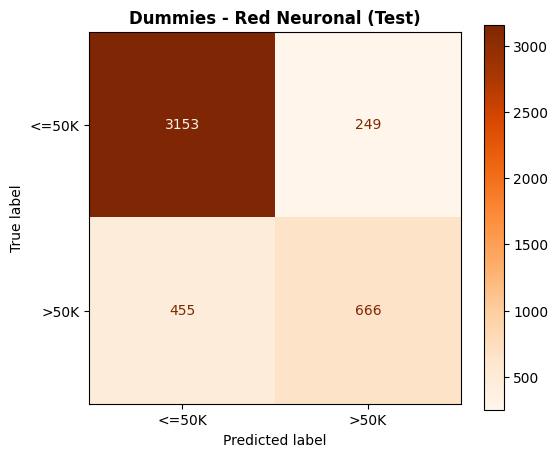

In [35]:
# La red devuelve una matriz de probabilidades continuas (ej: 0.78, 0.21...)
y_prob_red = model.predict(x_test_scaled)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_dumm, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Dummies - Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

Posterior a esto no voy a comparar las demás divisiones de dataset con recategorización y LabelEncoder sin estandarizar, ya que deducimos que si al no escalar los datos se obtienen resultados parecidos a la regresión logistica, no hay lógica en repetir información.

Pero, a pesar de ello voy a aplicar la red neuronal con estandarización en los demás datasets, y aquel que de mejor resultado va a ser el que voy a utilizar para las demás pruebas en busca de la optimización de nuestro modelo.

In [36]:
#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled_enc = scaler.fit_transform(x_train_enc)
x_val_scaled_enc = scaler.transform(x_val_enc)
x_test_scaled_enc = scaler.transform(x_test_enco)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled_enc.shape[1],), kernel_regularizer=l2(0.001)),

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
# Usamos 'Adam' como optimizador, 'binary_crossentropy' como función de pérdida para clasificación binaria,
# y 'accuracy' como métrica principal.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled_enc, y_train_enc,
    epochs=100, # Número máximo de épocas
    batch_size=32, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled_enc, y_val_enc), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled_enc, y_test_enco, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled_enc)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_enco, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8288 - loss: 0.4324 - val_accuracy: 0.8344 - val_loss: 0.3906
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8421 - loss: 0.3698 - val_accuracy: 0.8397 - val_loss: 0.3706
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8438 - loss: 0.3561 - val_accuracy: 0.8467 - val_loss: 0.3566
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8450 - loss: 0.3494 - val_accuracy: 0.8461 - val_loss: 0.3564
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8464 - loss: 0.3449 - val_accuracy: 0.8452 - val_loss: 0.3528

Entrenamiento completado.

Precisión del modelo en el conjunto de prueba: 0.8402
Pérdida del modelo en el conjunto de prueba: 0.3863
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step

Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

           0       0.88      0.91   

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step


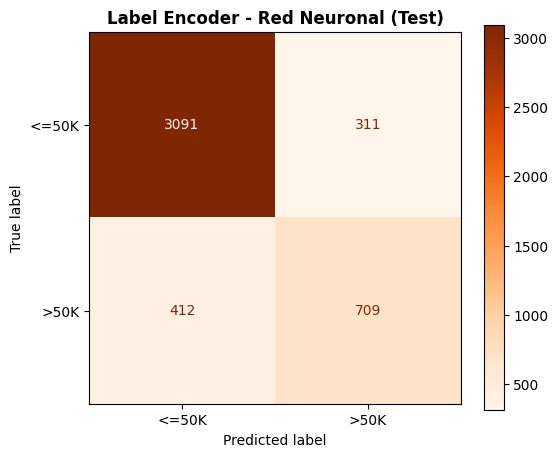

In [37]:
# La red devuelve una matriz de probabilidades continuas (ej: 0.78, 0.21...)
y_prob_red = model.predict(x_test_scaled_enc)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_enco, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Label Encoder - Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

In [38]:
#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled_rec = scaler.fit_transform(x_train_rec)
x_val_scaled_rec = scaler.transform(x_val_rec)
x_test_scaled_rec = scaler.transform(x_test_reca)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled_rec.shape[1],), kernel_regularizer=l2(0.001)),

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
# Usamos 'Adam' como optimizador, 'binary_crossentropy' como función de pérdida para clasificación binaria,
# y 'accuracy' como métrica principal.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled_rec, y_train_rec,
    epochs=100, # Número máximo de épocas
    batch_size=32, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled_rec, y_val_rec), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled_rec, y_test_reca, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled_rec)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_reca, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8354 - loss: 0.4176 - val_accuracy: 0.8437 - val_loss: 0.3760
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8462 - loss: 0.3594 - val_accuracy: 0.8419 - val_loss: 0.3580
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8481 - loss: 0.3458 - val_accuracy: 0.8459 - val_loss: 0.3489
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8495 - loss: 0.3404 - val_accuracy: 0.8445 - val_loss: 0.3455
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8490 - loss: 0.3359 - val_accuracy: 0.8408 - val_loss: 0.3456

Entrenamiento completado.

Precisión del modelo en el conjunto de prueba: 0.8432
Pérdida del modelo en el conjunto de prueba: 0.3773
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step

Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

           0       0.86      0.94   

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step


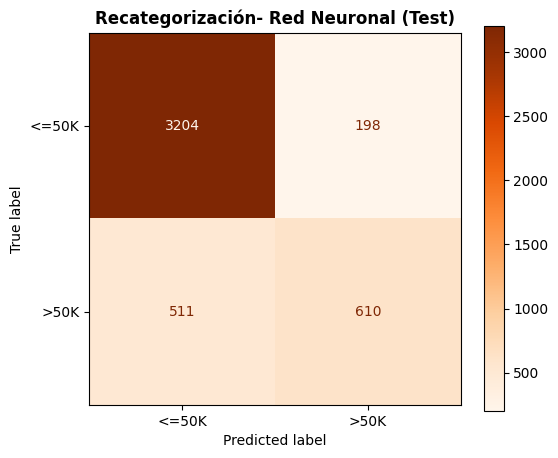

In [39]:
# La red devuelve una matriz de probabilidades continuas (ej: 0.78, 0.21...)
y_prob_red = model.predict(x_test_scaled_rec)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_reca, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Recategorización- Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

Al analizar todos los conjuntos de datos, vemos que hubo una mejora significativa en cada uno de ellos.
Pero nos quedaremos con aquel conjunto de datos con el pasaje con dummies.

Nota: Noté que cada vez que ejecutaba la red neuronal estandarizada comenzaba a errar más a la hora de predecir, por lo que los resultados del pasaje seleccionado también cambiaran.

Al principio los valores eran 0.67 en recall, y ahora son 0.54 y de f1-score tenia 0.66 siendo ahora de 0.62.
Aún que a comparación de antes es muy baja la diferencia, me parece extraño que al ejecutar el código repetidas veces empeore y no encuentre mejora.

**NOTA:** Voy a probar ahora en el modelo de dummies escalado si aplicando dropout logramos ver una mejora y además voy a agregar paciencia al aplicar el early stopping para también ver si cambia en algo.
Además quiero probas si al subir el batch_size, ya que para la cantidad de datos que tengo es bastante pequeño y quisiera ver que pasa si agrando la cantidad de gente que selecciona por grupo.

In [40]:
#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3), #Quiero probar con el valor estandar

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

#===============
#Learning Rate
#===============

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

#ME DI CUENTA QUE NO AGREGUÉ ESTA LINEA DE CÓDIGO EN LAS DEMÁS REDES, Y ANDUVO IGUAL, QUIERO VER QUE CAMBIA 
#Supongo que estuvo utilizando la que estaba al principio definida
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=32, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8206 - loss: 0.4711 - val_accuracy: 0.8368 - val_loss: 0.3938
Epoch 2/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8389 - loss: 0.3862 - val_accuracy: 0.8412 - val_loss: 0.3667
Epoch 3/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8419 - loss: 0.3652 - val_accuracy: 0.8395 - val_loss: 0.3631
Epoch 4/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8434 - loss: 0.3572 - val_accuracy: 0.8399 - val_loss: 0.3527
Epoch 5/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8434 - loss: 0.3544 - val_accuracy: 0.8445 - val_loss: 0.3515
Epoch 6/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8451 - loss: 0.3507 - val_accuracy: 0.8450 - val_loss: 0.3519
Epoch 7/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8453 - loss: 0.3485 - val_accuracy: 0.8439 - val_loss: 0.3485
Epoch 8/100
1131/1131 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - a

Nota: Me di cuenta que la línea de código que define el early stopping no la agregué en ninguna de las redes escaladas, por lo que supongo que estuvp utilizando la anteriormente definida en el modelo no escalado, por lo tanto estuvo utilizando patience y no es algo nuevo a utilizar.

Unicamente voy a probar el apagado de neuronas y el cambiar el batch_size.

En el caso de la red de arriba con el dropout hubo una mejora, pero unicamente de 0.02 en los dos casos (recall y f1-score), sin modificar ninguno de las otras metricas.

In [55]:
#DROPOUT Y BATCH SIZE DE 75 

#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3), #Quiero probar con el valor estandar

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

#ME DI CUENTA QUE NO AGREGUÉ ESTA LINEA DE CÓDIGO EN LAS DEMÁS REDES, Y ANDUVO IGUAL, QUIERO VER QUE CAMBIA 
#Supongo que estuvo utilizando la que estaba al principio definida
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=75, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_62 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6957 - loss: 0.7533 - val_accuracy: 0.7521 - val_loss: 0.6779
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7497 - loss: 0.6816 - val_accuracy: 0.7521 - val_loss: 0.6306
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7583 - loss: 0.6360 - val_accuracy: 0.7656 - val_loss: 0.5923
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7767 - loss: 0.6043 - val_accuracy: 0.7897 - val_loss: 0.5612
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7890 - loss: 0.5694 - val_accuracy: 0.8107 - val_loss: 0.5356
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8098 - loss: 0.5504 - val_accuracy: 0.8191 - val_loss: 0.5178
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8086 - loss: 0.5426 - val_accuracy: 0.8233 - val_loss: 0.5060
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8098 - loss: 

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step


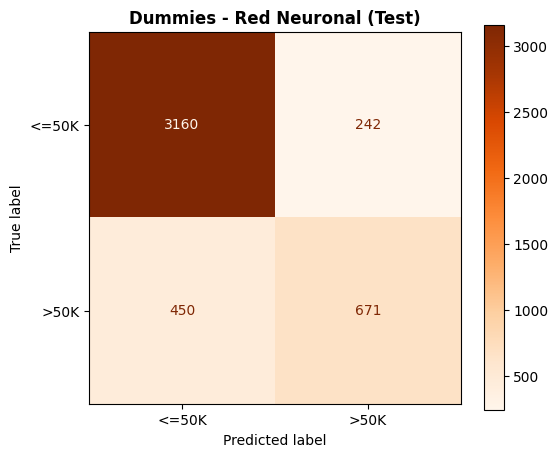

In [42]:
# La red devuelve una matriz de probabilidades continuas (ej: 0.78, 0.21...)
y_prob_red = model.predict(x_test_scaled)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_dumm, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Dummies - Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

Puedo observar una leve mejora en el recall y el f1-score sin afectar a las demás metricas, por lo que voy a optar con un batch size mucho más alto

In [43]:
#BATCH SIZE DE 200

#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3), #Quiero probar con el valor estandar

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

#ME DI CUENTA QUE NO AGREGUÉ ESTA LINEA DE CÓDIGO EN LAS DEMÁS REDES, Y ANDUVO IGUAL, QUIERO VER QUE CAMBIA 
#Supongo que estuvo utilizando la que estaba al principio definida
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=200, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7932 - loss: 0.5559 - val_accuracy: 0.8341 - val_loss: 0.4494
Epoch 2/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8259 - loss: 0.4498 - val_accuracy: 0.8392 - val_loss: 0.4114
Epoch 3/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8328 - loss: 0.4131 - val_accuracy: 0.8401 - val_loss: 0.3905
Epoch 4/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8379 - loss: 0.3921 - val_accuracy: 0.8419 - val_loss: 0.3765
Epoch 5/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8401 - loss: 0.3787 - val_accuracy: 0.8428 - val_loss: 0.3681
Epoch 6/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8429 - loss: 0.3684 - val_accuracy: 0.8452 - val_loss: 0.3627
Epoch 7/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8418 - loss: 0.3629 - val_accuracy: 0.8439 - val_loss: 0.3577
Epoch 8/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8442 

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step


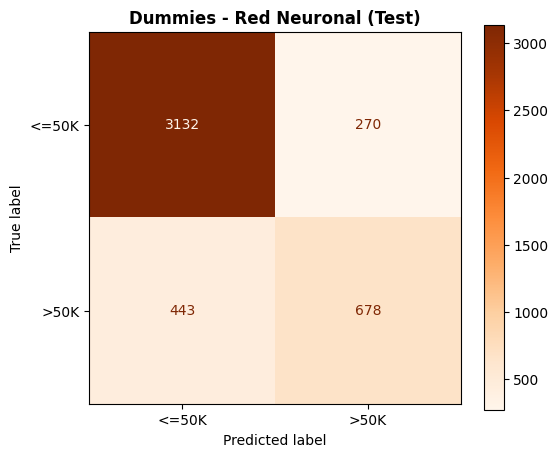

In [44]:
# La red devuelve una matriz de probabilidades continuas (ej: 0.78, 0.21...)
y_prob_red = model.predict(x_test_scaled)

# Transformamos: si la probabilidad es mayor a 0.5 es "1" (>50K), si no es "0" (<=50K)
y_pred_red = (y_prob_red > 0.5).astype(int)


# Calculamos la matriz comparando el Y real de test vs el Y predicho por la red
cm_red = confusion_matrix(y_test_dumm, y_pred_red)


fig, ax = plt.subplots(figsize=(6, 5))
disp_red = ConfusionMatrixDisplay(
    confusion_matrix=cm_red, 
    display_labels=['<=50K', '>50K']
)
disp_red.plot(ax=ax, cmap='Oranges', values_format='d') 

plt.title('Dummies - Red Neuronal (Test)', fontsize=12, fontweight='bold')
plt.grid(False) # Quitamos líneas de fondo molestas para la matriz
plt.show()

Al no encontrar ninguna mejora consistente en cambiar el batch size (32, 75, 200 y 500).

Voy a probar en agrandar la cantidad de neuronas a apagar y aumentar la paciencia.

Nota (18/06): Al tener que volver a ejecutar todo el código, este modelo con un batch_size de 200 terminó siendo el que dió un mejor resultado

In [56]:
#AUMENTAR DROPOUT 

#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.5), #Quiero probar con el valor estandar

    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

#ME DI CUENTA QUE NO AGREGUÉ ESTA LINEA DE CÓDIGO EN LAS DEMÁS REDES, Y ANDUVO IGUAL, QUIERO VER QUE CAMBIA 
#Supongo que estuvo utilizando la que estaba al principio definida
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=200, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6319 - loss: 0.7958 - val_accuracy: 0.7521 - val_loss: 0.7500
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7202 - loss: 0.7275 - val_accuracy: 0.7521 - val_loss: 0.7097
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7411 - loss: 0.7302 - val_accuracy: 0.7521 - val_loss: 0.6851
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7571 - loss: 0.7027 - val_accuracy: 0.7521 - val_loss: 0.6676
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7509 - loss: 0.7048 - val_accuracy: 0.7521 - val_loss: 0.6533
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7436 - loss: 0.6959 - val_accuracy: 0.7530 - val_loss: 0.6419
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7571 - loss: 0.6657 - val_accuracy: 0.7550 - val_loss: 0.6287
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7521 - loss: 0.6599 - val_acc


**CONLCUSIÓN MOMENTANEA DE LA RED NEURONAL:**

- Logramos observar que estandarizando el conjunto de datos y aplicando apagado de neuronas selectivas se consigue una mejora considerable en el aprendizaje del modelo.

- Además tras analizar varios valores en dropout (0.3, 0.4, 0.5), batch size (32, 75, 200, 500) y patience(5 y 10) no logramos ver una mejora considerable, más que un 0.04 en algunas metricas.
Por lo que el modelo de red neuronal más óptimo tiene una paciencia de 5, un dropout de 0.3 y un batch size de 75.

Con sus valores óptimos con precision = 0.75, recall= 0.58 y f1-score = 0.66 en la categoría objetivo de nuestra variable respuesta, sin sacrificar casi valores de la clase mayoritaría.

**POSTCLASE DE CONSULTA 10/06**: El profe declaró que podía pasar libremente al punto 4 del trabajo, donde realizo el cierre

Aclaración: Anteriormente intente realizar una grafico de lineas para comparar el train, dev y test. Pero después me di cuenta que lo calculaba sobre el accuracy, lo cual no me servia mucho, ya que la predicción es casi perfecta en el caso de la clase mayoritaría.
Por lo que primero busque un mejor f1-score ya que investigando decia que era el balance entre recall y precision, (uno era muy bajo y el otro muy alto), por lo que al intentar balancearlos me di cuenta que la metrica más importante era el recall, ya que cuando esta subia, el modelo aprendía más sobre la clase minoritaria sin la necesidad de perder mucho del otro lado.

Por lo que, el gráfico va a evaluar unicamente el test, dev y train de la clase minoritaria (>50K), y la métrica a utilizar para comparar las divisiones va a ser un f1-score aislado de la excelente predicción de la clase mayoritaria, para que no de engañosamente alto como ahora 

Problema: A pesar de usar el entorno virtual y que se guardar las respuestas de ejecución, al abrir nuevamente el documento me pide volver a ejecutar todo, ya que no se por que no quedan guardados los nombres de las variables ni demás datos. 

Por lo que, los números escritos en el análisis y nuevos resultados van a variar, ya que las respuestas no se repiten.

In [57]:
#Escalamos los datos 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_dum)
x_val_scaled = scaler.transform(x_val_dum)
x_test_scaled = scaler.transform(x_test_dumm)

In [69]:

# Implementación de la Red Neuronal con estandarización de datos y early stopping.
model = Sequential([
    # Capa de entrada y primera capa oculta con activación ReLU y regularización L2
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3), 
    # Segunda capa oculta con activación ReLU y regularización L2
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Tercera capa oculta con activación ReLU y regularización L2
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    # Capa de salida con activación sigmoide para clasificación binaria
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar un resumen del modelo
print("\nResumen del modelo de red neuronal:")
model.summary()

#ME DI CUENTA QUE NO AGREGUÉ ESTA LINEA DE CÓDIGO EN LAS DEMÁS REDES, Y ANDUVO IGUAL, QUIERO VER QUE CAMBIA 
#Supongo que estuvo utilizando la que estaba al principio definida
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
print("\nEntrenando el modelo...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100, # Número máximo de épocas
    batch_size=20, # Tamaño del lote para el entrenamiento
    validation_data=(x_val_scaled, y_val_dum), # Datos de validación
    callbacks=[early_stopping], # Aplicar Early Stopping
    verbose=1 # Mostrar progreso del entrenamiento
)

print("\nEntrenamiento completado.")

loss, accuracy = model.evaluate(x_test_scaled, y_test_dumm, verbose=0)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy:.4f}")
print(f"Pérdida del modelo en el conjunto de prueba: {loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred_proba = model.predict(x_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int) # Convertir probabilidades a clases binarias (0 o 1)

# Mostrar el reporte de clasificación
print("\nReporte de clasificación en el conjunto de prueba:")
print(classification_report(y_test_dumm, y_pred))


Resumen del modelo de red neuronal:


C:\Users\Urano\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,041 (43.13 KB)

 Trainable params: 11,041 (43.13 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo...
Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7202 - loss: 0.7319 - val_accuracy: 0.7521 - val_loss: 0.6282
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7656 - loss: 0.6191 - val_accuracy: 0.7950 - val_loss: 0.5650
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7975 - loss: 0.5603 - val_accuracy: 0.8087 - val_loss: 0.5276
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7939 - loss: 0.5422 - val_accuracy: 0.8145 - val_loss: 0.5077
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8209 - loss: 0.4971 - val_accuracy: 0.8176 - val_loss: 0.4937
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8356 - loss: 0.4960 - val_accuracy: 0.8149 - val_loss: 0.4881
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8233 - loss: 0.4841 - val_accuracy: 0.8187 - val_loss: 0.4812
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8209 - loss: 0.4790 

Luego de lo preguntado por el profe en clase, el aplicar el batch_size sin dropout se obtuvo el mismo resultado. 
Por lo mismo dicho, probé también un número más chico de selección de grupos y terminó resultando en los mismos valores en las métricas y perdida del aprendizaje.

Sobre el último valor probado se va a realizar el gráfico de lineas para su posterior análisis.

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step


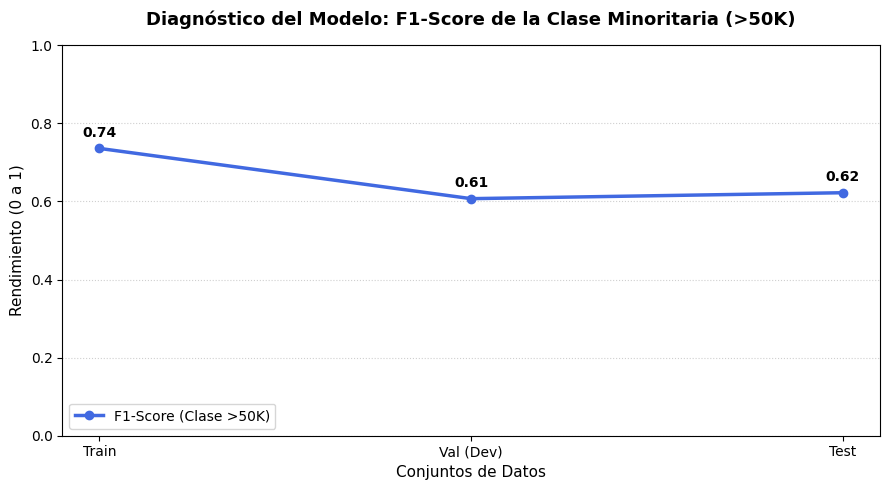

In [62]:
# 1. Realizar las predicciones binarias para los TRES conjuntos
preds_train = (model.predict(x_train_scaled) > 0.5).astype(int)
preds_val = (model.predict(x_val_scaled) > 0.5).astype(int)
preds_test = (model.predict(x_test_scaled) > 0.5).astype(int)

# 2. Calcular el F1-Score únicamente de la clase minoritaria (pos_label=1)
f1_train = f1_score(y_train_dum, preds_train, pos_label=1)
f1_val = f1_score(y_val_dum, preds_val, pos_label=1)
f1_test = f1_score(y_test_dumm, preds_test, pos_label=1)

# 3. Estructurar los datos para el gráfico
ejados = ['Train', 'Val (Dev)', 'Test']
valores_f1 = [f1_train, f1_val, f1_test]

# 4. Generar el gráfico de líneas de diagnóstico
plt.figure(figsize=(9, 5))
plt.plot(ejados, valores_f1, marker='o', linestyle='-', linewidth=2.5, color='royalblue', label='F1-Score (Clase >50K)')

# Configuraciones estéticas del gráfico
plt.title('Diagnóstico del Modelo: F1-Score de la Clase Minoritaria (>50K)', fontsize=13, pad=15, weight='bold')
plt.ylabel('Rendimiento (0 a 1)', fontsize=11)
plt.xlabel('Conjuntos de Datos', fontsize=11)
plt.ylim(0, 1) # Mantiene la escala real para ver la gravedad del desbalance
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='lower left')

# Añadir las etiquetas numéricas arriba de cada punto para la defensa
for i, valor in enumerate(valores_f1):
    plt.annotate(f"{valor:.2f}", (ejados[i], valores_f1[i] + 0.03), ha='center', color='black', weight='bold')

plt.tight_layout()
plt.show()


Entrenando el modelo y calculando métricas por época...
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8675 - loss: 0.3523 - val_accuracy: 0.8302 - val_loss: 0.4210
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8699 - loss: 0.3551 - val_accuracy: 0.8295 - val_loss: 0.4226
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8699 - loss: 0.3499 - val_accuracy: 0.8297 - val_loss: 0.4244
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8564 - loss: 0.3504 - val_accuracy: 0.8302 - val_loss: 0.4259
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8663 - loss: 0.3485 - val_accuracy: 0.8304 - val_loss: 0.4272
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8638 - loss: 0.3538 - val_accuracy: 0.8313 - val_loss: 0.4262

Entrenamiento completado.


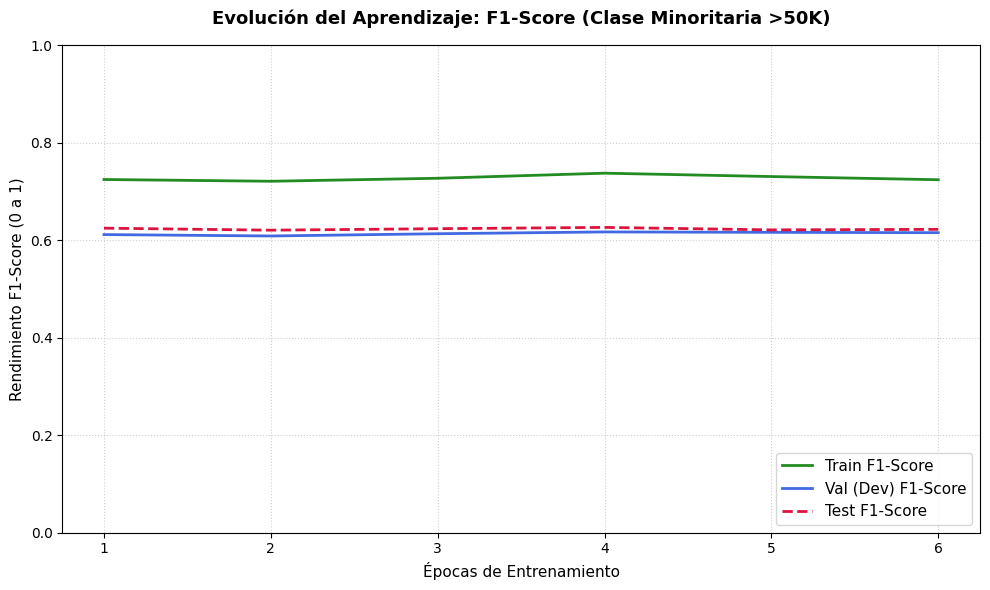

In [65]:
# 1. Creamos un Callback personalizado para evaluar Test en cada época
class TestF1History(Callback):
    def __init__(self, x_train, y_train, x_val, y_val, x_test, y_test):
        self.x_train = x_train
        self.y_train = y_train
        self.x_val = x_val
        self.y_val = y_val
        self.x_test = x_test
        self.y_test = y_test
        
        # Listas para guardar la historia
        self.train_f1 = []
        self.val_f1 = []
        self.test_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        # Predicciones de la época actual (umbral 0.5)
        preds_train = (self.model.predict(self.x_train, verbose=0) > 0.5).astype(int)
        preds_val = (self.model.predict(self.x_val, verbose=0) > 0.5).astype(int)
        preds_test = (self.model.predict(self.x_test, verbose=0) > 0.5).astype(int)
        
        # Calcular F1 aislado para la clase minoritaria (pos_label=1)
        self.train_f1.append(f1_score(self.y_train, preds_train, pos_label=1, zero_division=0))
        self.val_f1.append(f1_score(self.y_val, preds_val, pos_label=1, zero_division=0))
        self.test_f1.append(f1_score(self.y_test, preds_test, pos_label=1, zero_division=0))

# 2. Instanciamos nuestro callback con tus conjuntos escalados
f1_history = TestF1History(x_train_scaled, y_train_dum, x_val_scaled, y_val_dum, x_test_scaled, y_test_dumm)

# 3. Agregamos el callback al entrenamiento (mantenemos early_stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nEntrenando el modelo y calculando métricas por época...")
history = model.fit(
    x_train_scaled, y_train_dum,
    epochs=100,
    batch_size=75,
    validation_data=(x_val_scaled, y_val_dum),
    callbacks=[early_stopping, f1_history], # <--- Metemos el nuevo callback acá
    verbose=1
)

print("\nEntrenamiento completado.")

# 4. Generar el gráfico de líneas con las curvas completas
epochs_range = range(1, len(f1_history.train_f1) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, f1_history.train_f1, linestyle='-', linewidth=2, color='forestgreen', label='Train F1-Score')
plt.plot(epochs_range, f1_history.val_f1, linestyle='-', linewidth=2, color='royalblue', label='Val (Dev) F1-Score')
plt.plot(epochs_range, f1_history.test_f1, linestyle='--', linewidth=2, color='crimson', label='Test F1-Score')

# Configuraciones del gráfico
plt.title('Evolución del Aprendizaje: F1-Score (Clase Minoritaria >50K)', fontsize=13, pad=15, weight='bold')
plt.ylabel('Rendimiento F1-Score (0 a 1)', fontsize=11)
plt.xlabel('Épocas de Entrenamiento', fontsize=11)
plt.ylim(0, 1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

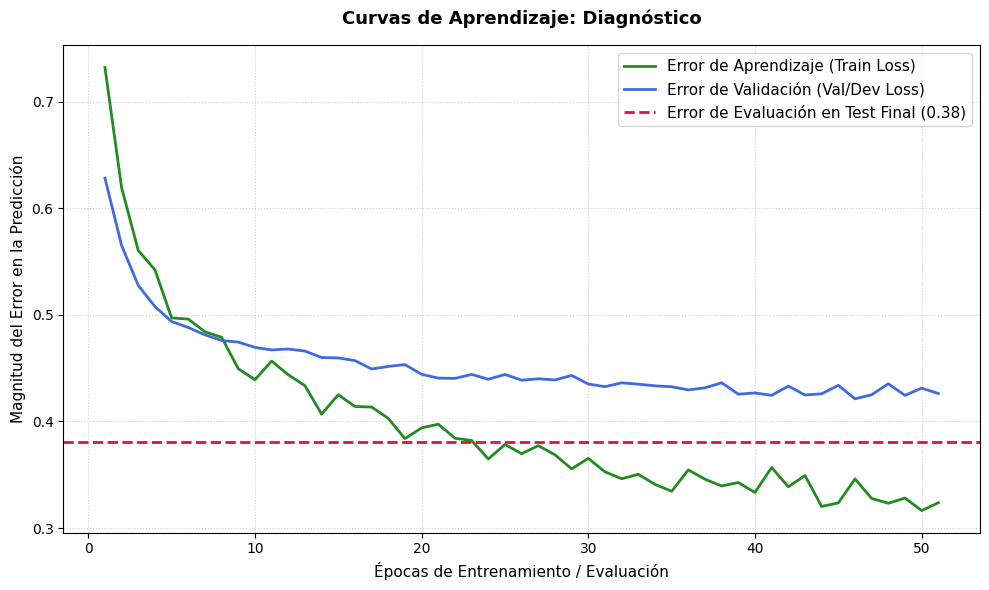

In [70]:
# 1. Extraer los datos de la pérdida (loss/error) del historial de entrenamiento
# Usamos la pérdida que representa directamente el error matemático en el eje Y
error_train = history.history['loss']
error_val = history.history['val_loss']
epocas = range(1, len(error_train) + 1)

# 2. Calcular el error final de Test de la clase minoritaria para la línea de control
y_pred_test = (model.predict(x_test_scaled, verbose=0) > 0.5).astype(int)
f1_test_minoritaria = f1_score(y_test_dumm, y_pred_test, pos_label=1)
error_test_final = 1 - f1_test_minoritaria

# 3. Construir el gráfico de curvas de aprendizaje
plt.figure(figsize=(10, 6))

# Líneas completas de evolución (Eje X: Épocas/Datos procesados - Eje Y: Magnitud del Error)
plt.plot(epocas, error_train, linestyle='-', linewidth=2, color='forestgreen', label='Error de Aprendizaje (Train Loss)')
plt.plot(epocas, error_val, linestyle='-', linewidth=2, color='royalblue', label='Error de Validación (Val/Dev Loss)')

# Línea de control del Test Final
plt.axhline(y=error_test_final, color='crimson', linestyle='--', linewidth=2, 
            label=f'Error de Evaluación en Test Final ({error_test_final:.2f})')

# Ajustes de los ejes y formato del diagnóstico
plt.title('Curvas de Aprendizaje: Diagnóstico', fontsize=13, pad=15, weight='bold')
plt.xlabel('Épocas de Entrenamiento / Evaluación', fontsize=11)
plt.ylabel('Magnitud del Error en la Predicción', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

**NOTA**: Tenía una idea equivocada al querer mostrar como entrenaba, validaba y testeaba el modelo. 
- Primer Pensamiento (errado): en los gráficos anteriores al último creía que tenia que evaluar las divisiónes por separado con las metricas, por eso mismo mencioné que utilizaría el f1-score (de esa idea se generó el primer gráfico) 
A partir de ahí me di cuenta que no era el mismo que el visto en clase, por lo que busque para que sean tres líneas, separando las divisiones pero no era lo que buscaba.

Por lo que investigué y en realidad se llama curva de aprendizaje y no es lo mismo, puesto que no puedo aplicarla a una sección especifica del dataset, sino a la totalidad del mismo. Por lo que no puedo evaluar la categoría minoritaria por separado.

**CONCLUSIÓN:** 

Concluyendo con la práctica, logro observar que la estandarización ayudo con todas aquellas observaciones atipicas, por lo que no interfirieron a la hora de entrenar el modelo.

Posterior a eso logro ver que, a pesar de que el entrenamiento comienza con un error muy alto, al avanzar logra ser incluso más bajo que el del test. 
Además (con información que no terminé guardando en el archivo oficial) el conjunto de validación termina siendo una base clave para que la red no siguiera entrenando a ciegas en el Early Stopping durante las 100 épocas. Puesto a que antes mi dataset tenía unicamente dos divisiones (train y test) logro observar que si esta nueva división no estuviera, al entrenar, el modelo seguiría bajando el error a costa de memorizar el ruido, pero al evaluar el test al final de todo, el error se vería disparado.

Por lo que considero que el dataset Adult Income está un poco sesgado, no por poca capacidad del modelo si no por el propio techo de aprendizaje que tiene el mismo conjunto de datos, al contener tan poca información o diferenciación entre las categorías de nuestra variable respuesta.

Logro destacar por lo mismo, que el aprendizaje es óptimo en Redes Neuronales, sin embargo priorizo que el desempeño en la clase categorica preferencial sigue siendo un valor muy bajo para lo que se busca, pero bastante aceptable en comparación con la poca información proporcionada y diferencia en cantidad de datos entre categorías de la variable respuesta.


Aprendizaje de la matería: Sinceramente me ayudó mucho más a centrarme en el código y aprender cosas que en materias anteriores al tener unicamente la teoría confundia facilmente.
También me ayudó a ver errores más comunes en ambitos de como suelo hacer las cosas, dandome cuenta que a veces me centro en el más minimo detalle y no logro llegar nunca al punto importante del análisis. 
Por último las limitaciones del tiempo me dejó deseo de probar los modelos de pipeline que no logré aplicar (Bayes Ingenuo, Boosting y Clasificación de Soporte Vectorial (aún teniendo dudas sobre este último)), además me hubiera gustado probar si a pesar de la eliminación de variables, el aprendizaje hubiera cambiado mucho (suponiendo que al ser parecidas siguen un mismo camino y tienen un mismo aporte).

Por último, quisiera más allá de los temas de la materia, realizar un análisis del dataset, como si fuera una análista y tuviera objetivos o patrones que encontrar, para evalúar las variables por separado, determinar si verdaderamente algunas variables son las más influyentes y hacer un reporte sobre el mismo. Creo que a la hora de aplicar los modelos simplificaría mucho más las tareas, ya que nos facilitarían mucho más encontrar los errores y corregirlos y no probar al azar cual podría mejorar la predicción.